# Potato Blight Classification

**by Group 1**


---

## 1: Business Understanding

### 1.1 Business Context

Many smallholder farmers depend on potato yields for both subsistence and income. However, potato crops are highly vulnerable to fungal diseases - most notably **Early Blight** (*Alternaria solani*) and **Late Blight** (*Phytophthora infestans*). Left undetected, these diseases can devastate 30 - 70% of a crop, causing severe food insecurity and financial loss.

Traditional disease identification relies on experts conducting in-person field inspections - a resource that most smallholder farmers cannot access in time. By the point visible symptoms have spread, the window for effective treatment is often already closed.

This project builds an **automated potato blight classification system** using the PlantVillage dataset and a MobileNetV2 deep learning architecture. The model classifies leaf images into three categories - **Early Blight**, **Late Blight**, and **Healthy** - enabling rapid, low-cost diagnosis directly from a smartphone photo.


### 1.2 Stakeholders

| Stakeholder | Interest |
|---|---|
| **Smallholder Farmers** | Early, accurate disease diagnosis to protect yield and income |
| **Agricultural Officers** | A scalable tool to assist field services |
| **NGOs & Food Security Bodies** | Reduction of crop loss in vulnerable communities |

### 1.3 Project Plan (CRISP-DM Phases)

```
Phase 1: Business Understanding
Phase 2: Data Understanding
Phase 3: Data Preparation
Phase 4: Modeling
Phase 5: Evaluation
Phase 6: Deployment
```

**Deliverables:**
- Jupyter Notebook 
- GitHub Repository
- Deployment
- Non-Technical Presentation

---

## 2: Data Understanding

### 2.1 Overview - PlantVillage Potato Subset

The dataset is sourced from the **PlantVillage** project, a large-scale open dataset of plant leaf imagery developed at Penn State University. The full PlantVillage dataset covers 38 disease classes across 14 crop species; this project uses the **potato subset only**, consisting of 2,152 images across three classes.

| Class Folder | Disease | Images (approx.) | Share |
|---|---|---|---|
| `Potato___Early_blight` | *Alternaria solani* fungal infection | 1,000 | ~46 % |
| `Potato___Late_blight` | *Phytophthora infestans* water mould | 1,000 | ~46 % |
| `Potato___healthy` | No visible disease | 152 | ~7 % |



### 2.2 Import Libraries

In [1]:
# Imports

import os
import cv2
import PIL
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
import warnings
warnings.filterwarnings('ignore')


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import (
    layers, Model, Sequential
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

print(f'TensorFlow  : {tf.__version__}')
print(f'GPUs visible: {len(tf.config.list_physical_devices("GPU"))}')

TensorFlow  : 2.3.1
GPUs visible: 0


### 2.3 Configuration

In [2]:
# for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Hyper-parameters 
IMG_SIZE    = 224          # MobileNetV2 expects 224Ã—224
BATCH_SIZE  = 32
EPOCHS_HEAD = 15           # train only the new head
EPOCHS_FINE = 20           # fine-tune top layers of base
LR_HEAD     = 1e-3
LR_FINE     = 5e-5
UNFREEZE_FROM = 130        # unfreeze MobileNetV2 layers from this index onward

CLASS_NAMES = ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
LABEL_MAP   = {c: i for i, c in enumerate(CLASS_NAMES)}
DISPLAY_NAMES = ['Early Blight', 'Late Blight', 'Healthy']


DATASET_DIR = 'PlantVillage'  
CHECKPOINT_PATH = 'best_potato_model.h5'

### 2.4 Class Distribution

In [3]:
def count_images(dataset_dir, class_names):
    records = []
    for cls in class_names:
        cls_path = os.path.join(dataset_dir, cls)
        files = [
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        records.append({
            'class':   cls,
            'display': DISPLAY_NAMES[CLASS_NAMES.index(cls)],
            'count':   len(files)
        })
    return pd.DataFrame(records)

dist_df = count_images(DATASET_DIR, CLASS_NAMES)
dist_df['pct'] = (dist_df['count'] / dist_df['count'].sum() * 100).round(1)
print(dist_df[['display', 'count', 'pct']].to_string(index=False))
print(f"\nTotal images: {dist_df['count'].sum()}")

     display  count  pct
Early Blight   1000 46.5
 Late Blight   1000 46.5
     Healthy    152  7.1

Total images: 2152


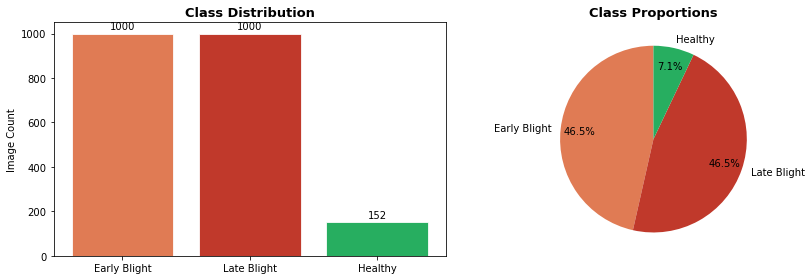

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#e07b54', '#c0392b', '#27ae60']

axes[0].bar(dist_df['display'], dist_df['count'], color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Image Count')
for bar, cnt in zip(axes[0].patches, dist_df['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(cnt), ha='center', va='bottom', fontsize=10)

axes[1].pie(dist_df['count'], labels=dist_df['display'], colors=colors,
            autopct='%1.1f%%', startangle=90, pctdistance=0.8)
axes[1].set_title('Class Proportions', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

**Insights**

`Class Imbalance:` The healthy class accounts for only ~7% of the dataset. Without corrective measures (class weighting), a naive model could achieve ~93% accuracy by simply predicting disease every time - while entirely failing to identify healthy plants. This is why Macro F1 is the primary metric.


### 2.5 Sample Image Grid

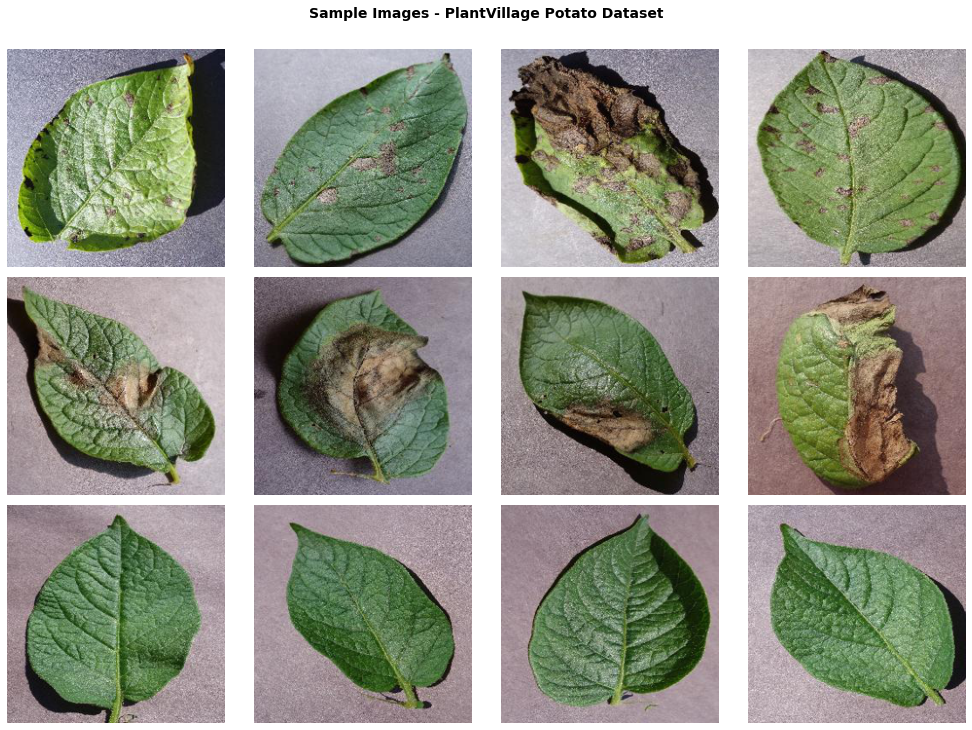

In [5]:
from PIL import Image

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Sample Images - PlantVillage Potato Dataset', fontsize=14, fontweight='bold', y=1.01)

for row, (cls, dname) in enumerate(zip(CLASS_NAMES, DISPLAY_NAMES)):
    cls_dir = os.path.join(DATASET_DIR, cls)
    samples = np.random.choice(os.listdir(cls_dir), 4, replace=False)
    for col, fname in enumerate(samples):
        img = Image.open(os.path.join(cls_dir, fname)).resize((224, 224))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(dname, fontsize=11, fontweight='bold', rotation=0,
                                      labelpad=80, va='center')

plt.tight_layout()
plt.show()

## 3: Data Preparation

### 3.1 Build File List & Stratified Split

In [6]:
def build_file_list(dataset_dir, class_names):
    """Return (paths, labels) arrays with integer label encoding."""
    paths, labels = [], []
    for cls in class_names:
        cls_dir = os.path.join(dataset_dir, cls)
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                paths.append(os.path.join(cls_dir, fname))
                labels.append(LABEL_MAP[cls])
    return np.array(paths), np.array(labels)
all_paths, all_labels = build_file_list(DATASET_DIR, CLASS_NAMES)
print(f'Total files loaded: {len(all_paths)}')
# Stratified split: 70 % train / 15 % val / 15 % test
X_train, X_temp, y_train, y_temp = train_test_split(
    all_paths, all_labels, test_size=0.30, stratify=all_labels, 
random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)
print(f'Train : {len(X_train)} images')
print(f'Val   : {len(X_val)}  images')
print(f'Test  : {len(X_test)}  images')

Total files loaded: 2152
Train : 1506 images
Val   : 323  images
Test  : 323  images


`Why stratified splits?` Stratification ensures each split preserves the original class
proportions. 

Without it, the rare healthy class (only ~152 images) could be randomly
absent or over-concentrated in one split, making validation metrics unreliable.

### 3.2. Class Weights

In [7]:
class_weights_arr = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights_arr))

**Interpretation:** `compute_class_weight('balanced', ...)` assigns each class a weight inversely proportional to its frequency. The healthy class will receive a much higher weight than the disease classes, penalising the model more heavily formisclassifying the rare class during training.


### 3.3. tf.data Pipeline

`load and preprocess` will read image, resize, and scale to [-1, 1]

augmentation will only be applied in training

In [8]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
def load_and_preprocess_image(path, label):
    raw   = tf.io.read_file(path)
    image = tf.image.decode_image(raw, channels=3)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label
    
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    k     = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k=k)
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.image.random_saturation(image, 0.8, 1.2)
    image = tf.image.random_hue(image, 0.05)
    frac     = tf.random.uniform([], 0.85, 1.0)
    crop_sz  = tf.cast(tf.cast(IMG_SIZE, tf.float32) * frac, tf.int32)
    image    = tf.image.random_crop(image, [crop_sz, crop_sz, 3])
    image    = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image    = tf.clip_by_value(image, -1.0, 1.0)
    return image, label

cw_tensor = tf.constant([class_weight_dict[i] for i in range(len(CLASS_NAMES))], dtype=tf.float32)

def make_dataset(paths, labels, augment_flag=False, shuffle=False, add_weights=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    if augment_flag:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    if add_weights:
        # Embed per-sample class weights directly in the dataset.
        ds = ds.map(lambda img, lbl: (img, lbl, cw_tensor[lbl]))
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, augment_flag=True,  shuffle=True,  add_weights=True)
val_ds   = make_dataset(X_val,   y_val,   augment_flag=False, shuffle=False)
test_ds  = make_dataset(X_test,  y_test,  augment_flag=False, shuffle=False)
print("Datasets ready.")
for images, labels, weights in train_ds.take(1):
    print(f"  Batch shape: {images.shape}, label dtype: {labels.dtype}, weights: {weights.numpy()[:4]}")

Datasets ready.
  Batch shape: (32, 224, 224, 3), label dtype: <dtype: 'int32'>, weights: [0.7171429 0.7171429 0.7171429 0.7171429]


**Augmentation rationale**: With only 2,152 images, the training set is small enough that
overfitting is a real risk. The augmentation pipeline applies a range of realistic
photometric and geometric transforms (flips, brightness shifts, saturation changes,
random crop) to synthetically expand training diversity. Augmentation is applied only to
the training set â€” validation and test sets always use the clean, unmodified images to
ensure the evaluation reflects real-world deployment conditions.

In [9]:
# Custom Macro F1 Metric

class MacroF1Score(keras.metrics.Metric):
    def __init__(self, num_classes, name='macro_f1', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.tp = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros')
        self.fp = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros')
        self.fn = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros')


    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_cls = tf.argmax(y_pred, axis=-1, output_type=tf.int32)

        y_true_i32 = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred_oh  = tf.one_hot(y_pred_cls, self.num_classes)   
        y_true_oh  = tf.one_hot(y_true_i32, self.num_classes)   
        self.tp.assign_add(tf.reduce_sum(y_pred_oh * y_true_oh,         axis=0))
        self.fp.assign_add(tf.reduce_sum(y_pred_oh * (1 - y_true_oh),   axis=0))
        self.fn.assign_add(tf.reduce_sum((1 - y_pred_oh) * y_true_oh,   axis=0))

    def result(self):
        eps = 1e-7
        precision = self.tp / (self.tp + self.fp + eps)
        recall    = self.tp / (self.tp + self.fn + eps)
        f1_per    = 2 * precision * recall / (precision + recall + eps)
        return tf.reduce_mean(f1_per)

    def reset_states(self):   
        self.tp.assign(tf.zeros(self.num_classes))
        self.fp.assign(tf.zeros(self.num_classes))
        self.fn.assign(tf.zeros(self.num_classes))

    def get_config(self):     # required so load_model can reconstruct the metric
        config = super().get_config()
        config['num_classes'] = self.num_classes
        return config

print('MacroF1Score metric defined.')

MacroF1Score metric defined.


`Macro-averaged F1 score tracked per batch accumulation.`

**Why a custom metric?** Keras's built-in F1 implementation is not available in all TensorFlow versions, and sklearn's `f1_score` cannot be integrated into the training loop. This custom metric accumulates per-class TP, FP, and FN across batches and computes the final Macro F1 at the end of each epoch 


---
## 4: Baseline Models

Before training MobileNetV2, we establish baseline performance using simple,
interpretable models. This lets us quantify how much value the deep learning
approach actually adds.

  1. Logistic Regression on raw pixels
  2. CNN from scratch 

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import time


def dataset_to_numpy(ds):
    images_list, labels_list = [], []
    for batch in ds:
        images_list.append(batch[0].numpy())
        labels_list.append(batch[1].numpy())
    X = np.concatenate(images_list).reshape(len(np.concatenate(labels_list)), -1)
    y = np.concatenate(labels_list)
    return X, y

print("Flattening datasets for baseline log regression...")
X_train_flat, y_train_flat = dataset_to_numpy(train_ds)
X_test_flat,  y_test_flat  = dataset_to_numpy(test_ds)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled  = scaler.transform(X_test_flat)
print(f"Train shape: {X_train_flat.shape} | Test shape: {X_test_flat.shape}")


Flattening datasets for baseline log regression...
Train shape: (1506, 150528) | Test shape: (323, 150528)


In [11]:
# Baseline 1: Logistic Regression on pixel intensity values (no feature extraction) 
print("\n--- Baseline 1: Logistic Regression ---")

# PCA to reduce dimensions
from sklearn.decomposition import PCA

print("Fitting PCA (150 components)...")
pca = PCA(n_components=150, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.1%}")

t0 = time.time()
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',   # mirrors the class weighting used in the CNN
    random_state=SEED,
    C=1.0
)
lr.fit(X_train_pca, y_train_flat)
lr_preds = lr.predict(X_test_pca)
lr_f1 = f1_score(y_test_flat, lr_preds, average='macro')
print(f"Macro F1: {lr_f1:.4f}  ({time.time()-t0:.1f}s)")
print(classification_report(y_test_flat, lr_preds, target_names=DISPLAY_NAMES))


--- Baseline 1: Logistic Regression ---
Fitting PCA (150 components)...
Explained variance: 81.3%
Macro F1: 0.3520  (0.5s)
              precision    recall  f1-score   support

Early Blight       0.53      1.00      0.69       150
 Late Blight       0.89      0.23      0.36       150
     Healthy       0.00      0.00      0.00        23

    accuracy                           0.57       323
   macro avg       0.48      0.41      0.35       323
weighted avg       0.66      0.57      0.49       323



`PCA before Logistic Regression` is necessary because 224Ã—224Ã—3 = 150,528 features would cause convergence failure and memory issues. 150 components typically captures 70â€“80% of variance.

In [12]:
# Baseline 2: Tiny CNN from scratch (no transfer learning)
print("\n--- Baseline 2: Tiny CNN (no pre-training) ---")

def build_tiny_cnn(num_classes=3):
    return Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(16, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(2),

        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.GlobalAveragePooling2D(),

        layers.Dense(64, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax'),
    ])

tiny_cnn = build_tiny_cnn()
tiny_cnn.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', MacroF1Score(num_classes=3)]
)
tiny_cnn.summary()

tiny_callbacks = [
    EarlyStopping(monitor='val_macro_f1', mode='max',
                  patience=5, restore_best_weights=True, verbose=1),
]

tiny_history = tiny_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,

    callbacks=tiny_callbacks,
    verbose=1
)

tiny_preds = np.argmax(tiny_cnn.predict(test_ds), axis=1)
tiny_f1 = f1_score(y_test_flat, tiny_preds, average='macro')
print(f"Macro F1: {tiny_f1:.4f}")
print(classification_report(y_test_flat, tiny_preds, target_names=DISPLAY_NAMES))


--- Baseline 2: Tiny CNN (no pre-training) ---
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 224, 224, 16)      448       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 112, 112, 16)      0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 112, 112, 32)      4640      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 56, 56, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 56, 56, 64)        18496     
_________________________________________________________________
global_average_pooling2d (Gl (None, 64)                0         
_________________________________________________________________
dense (D

`***Overview of the CNN process in Computer Vision:***`

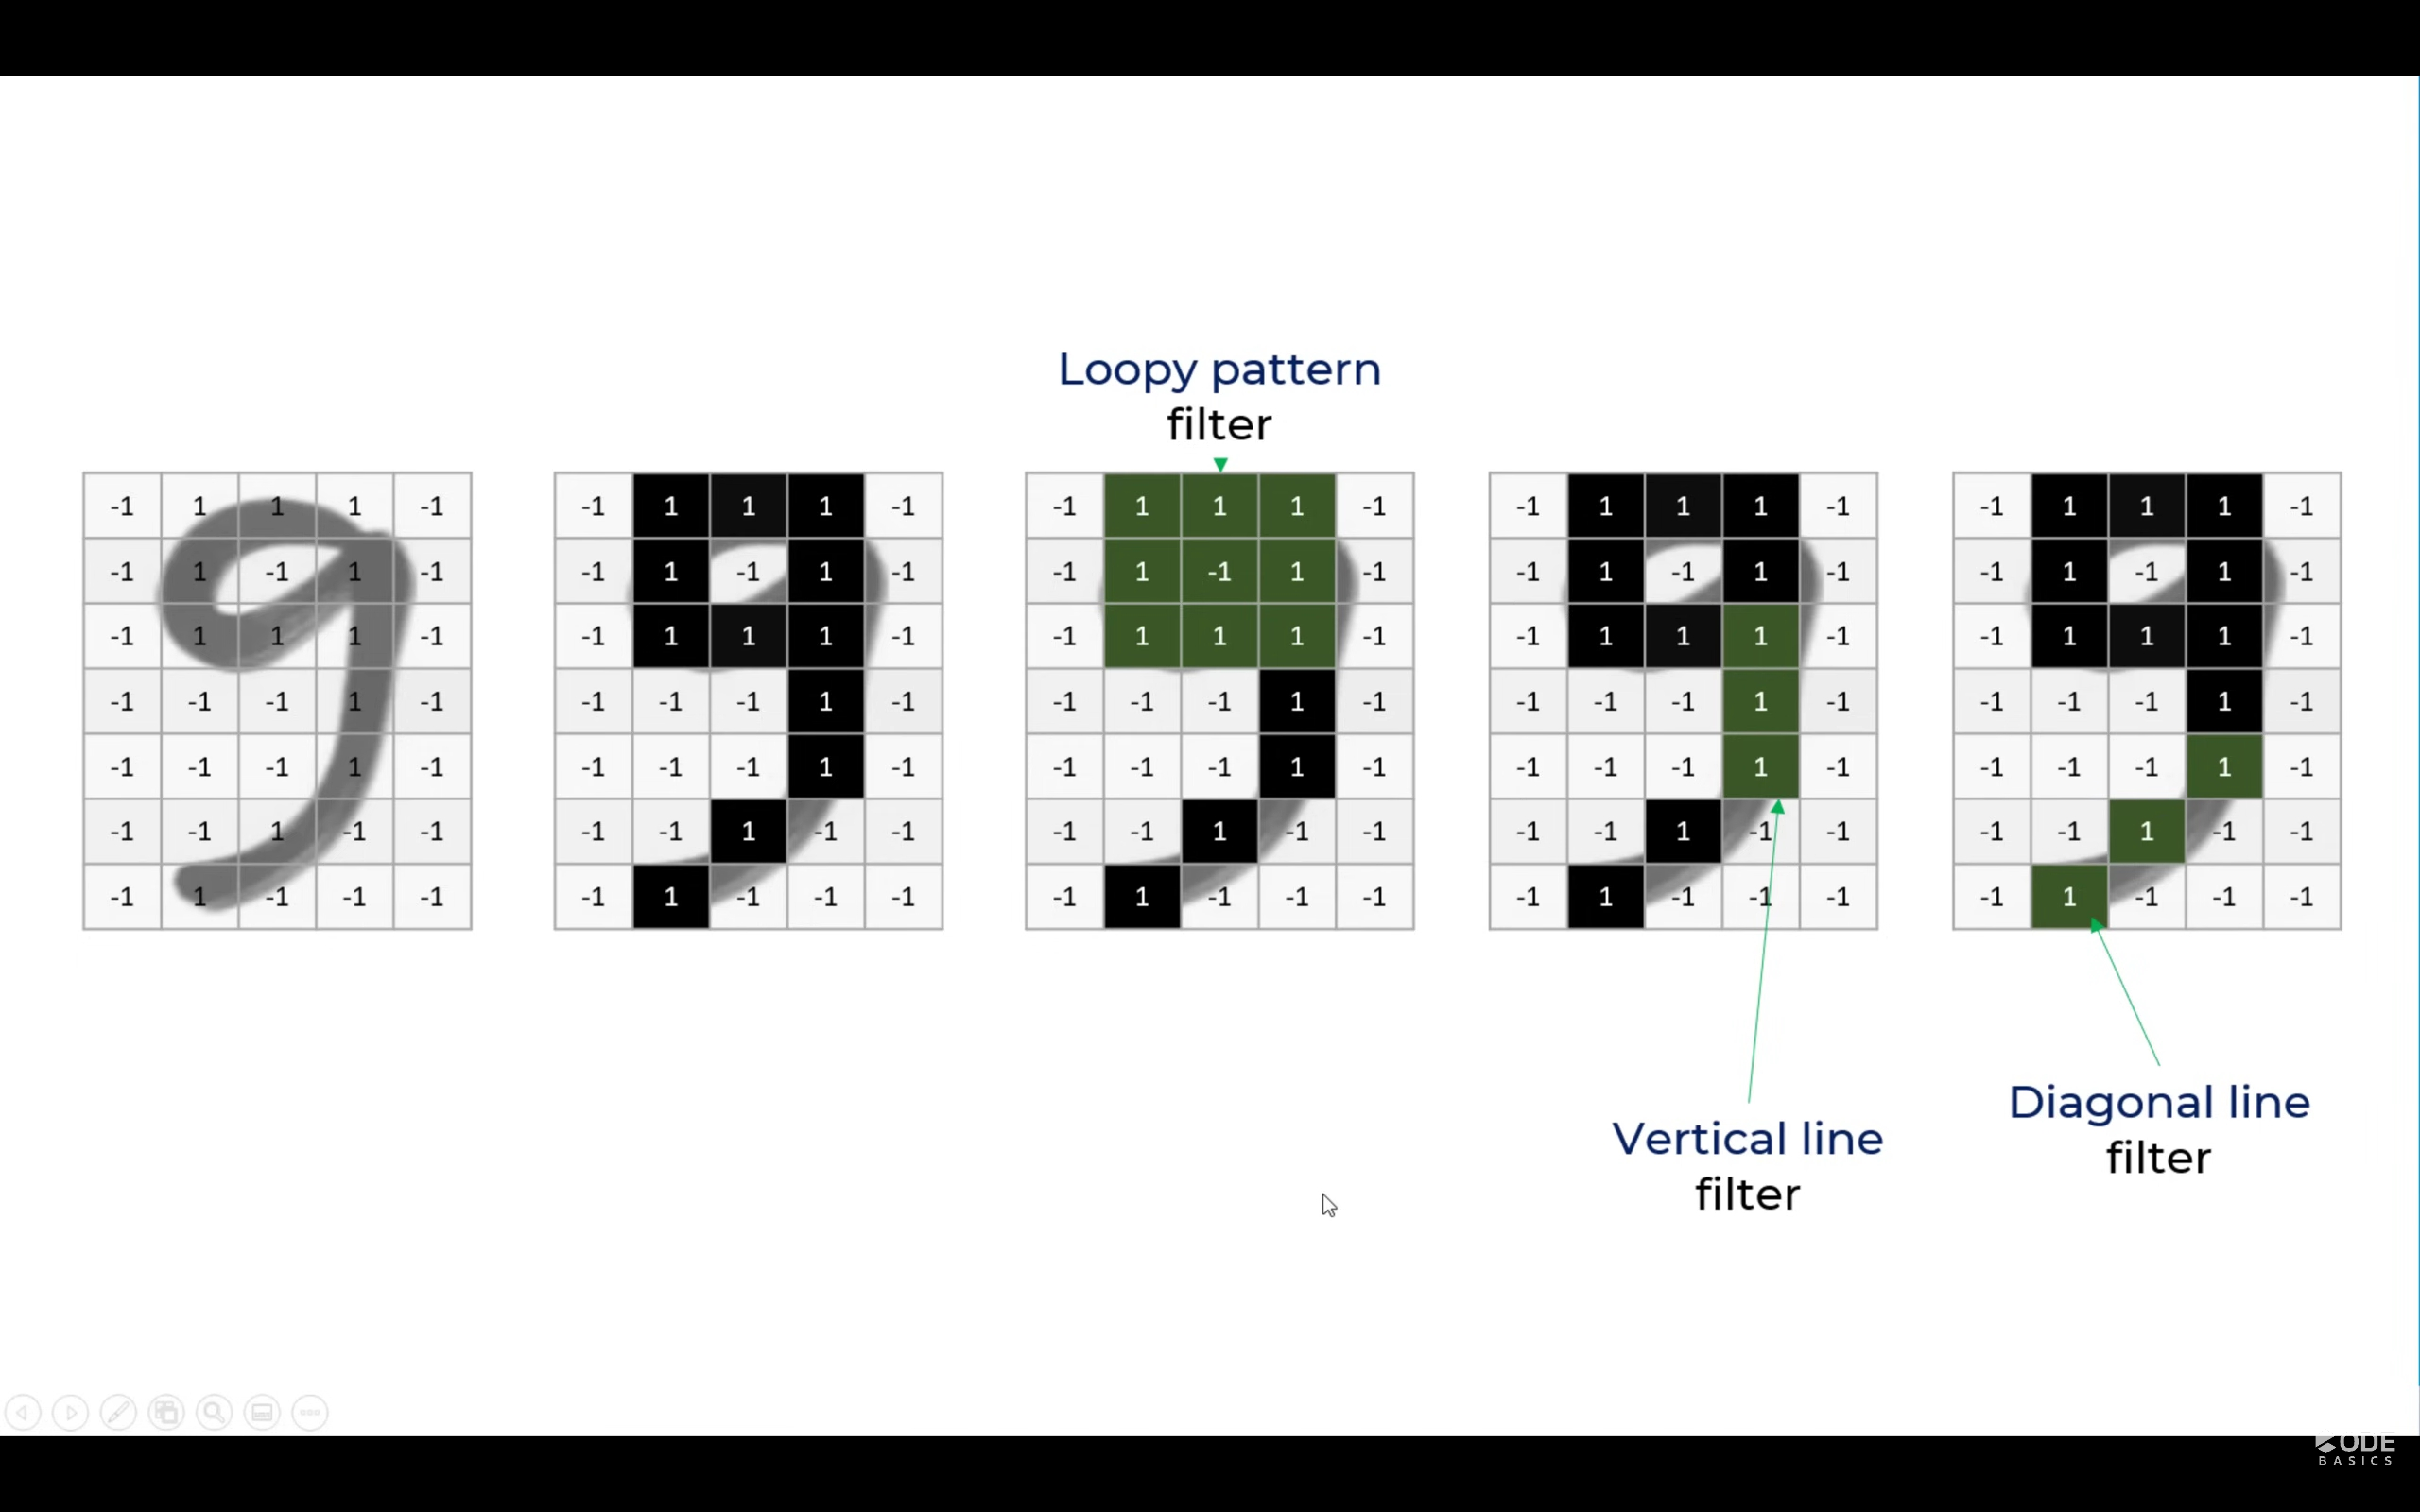

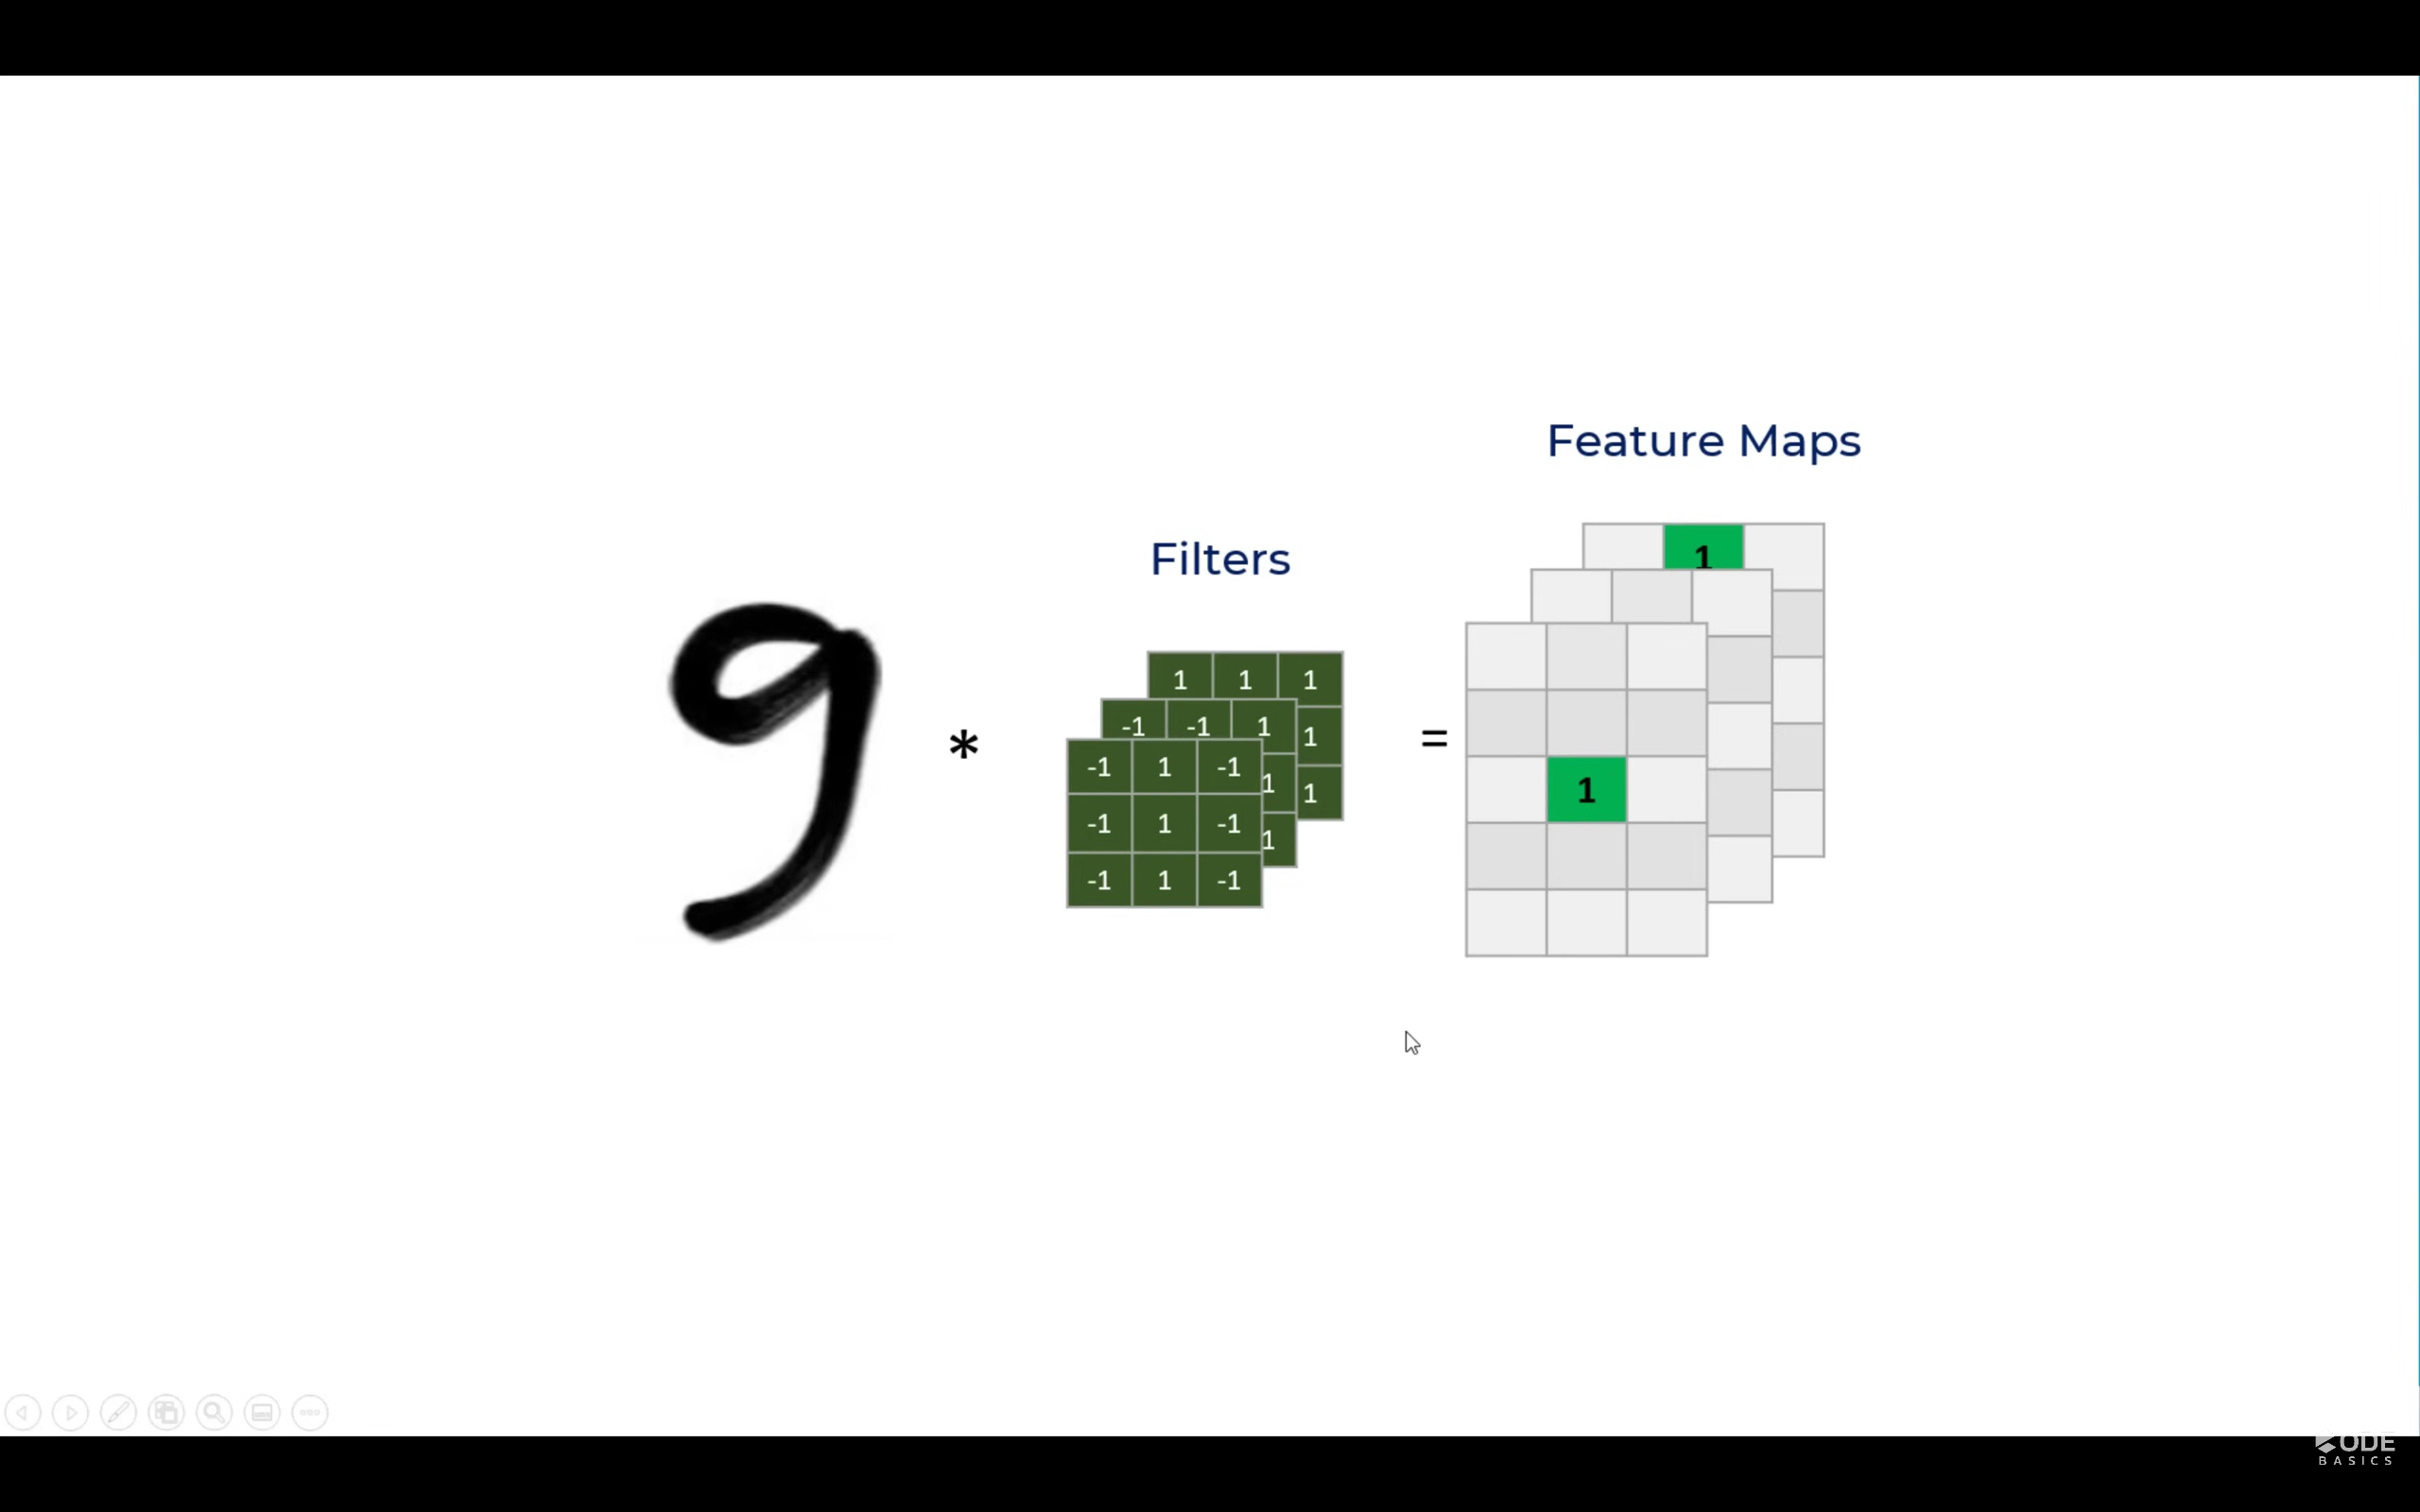

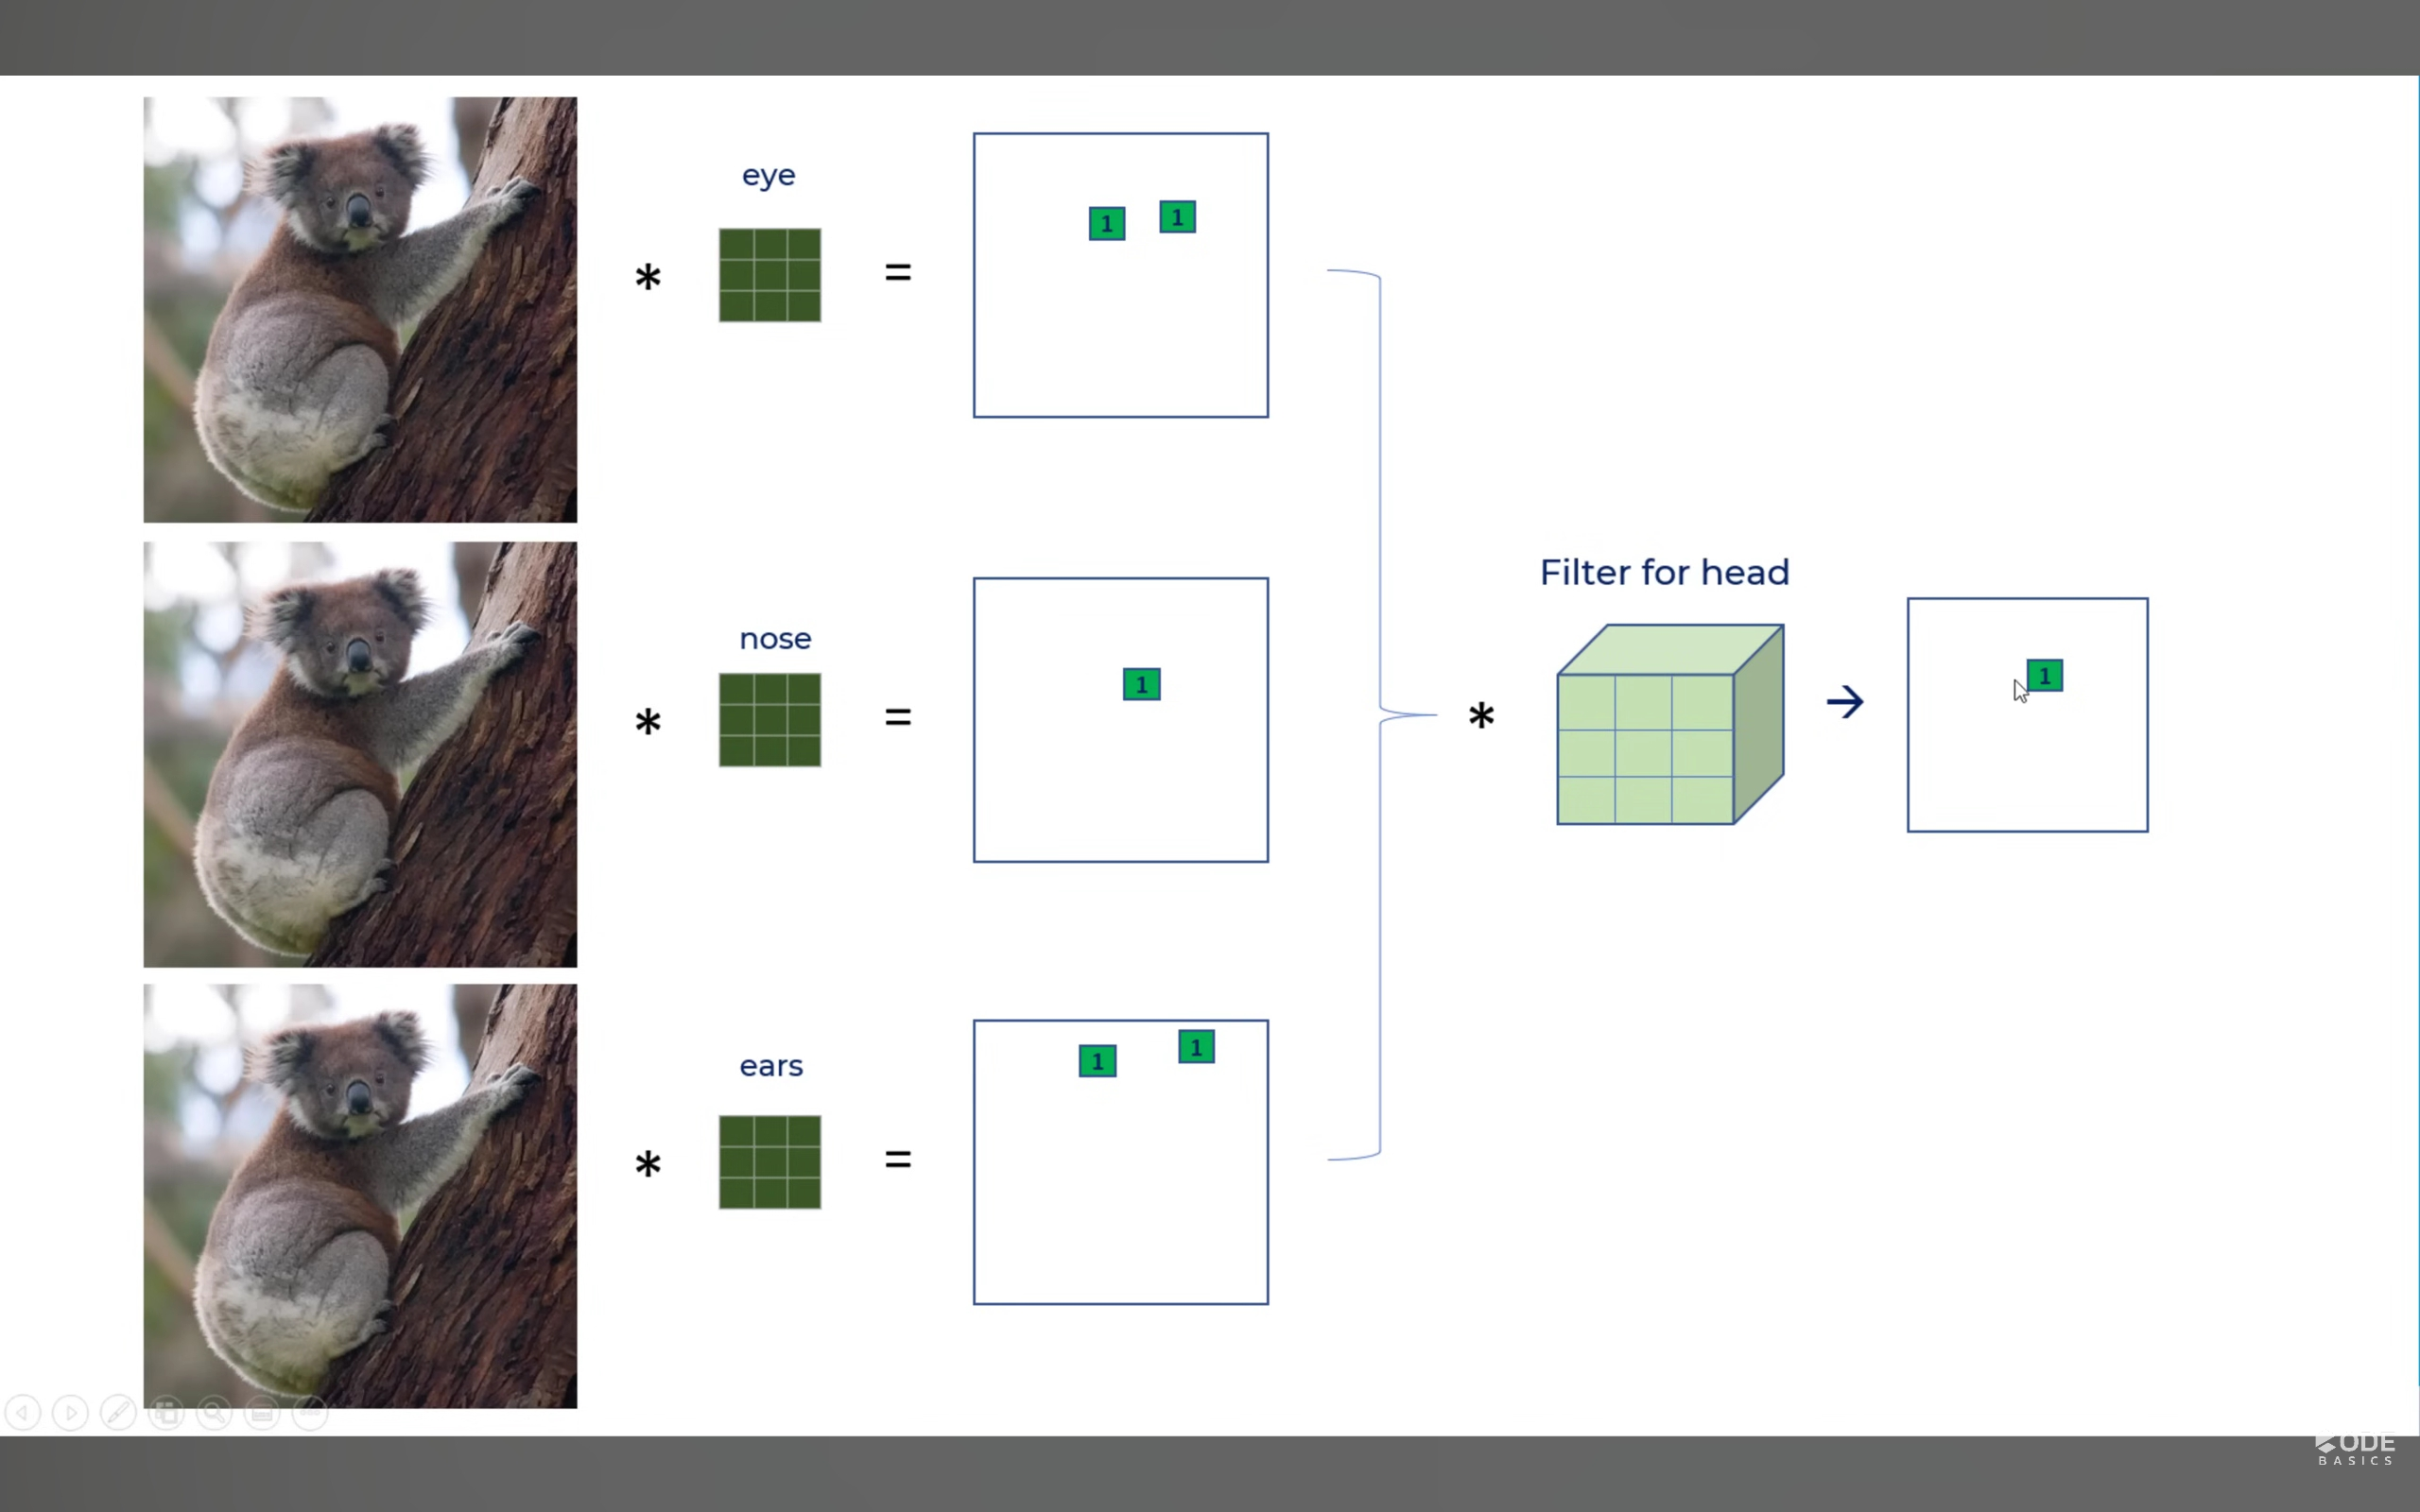

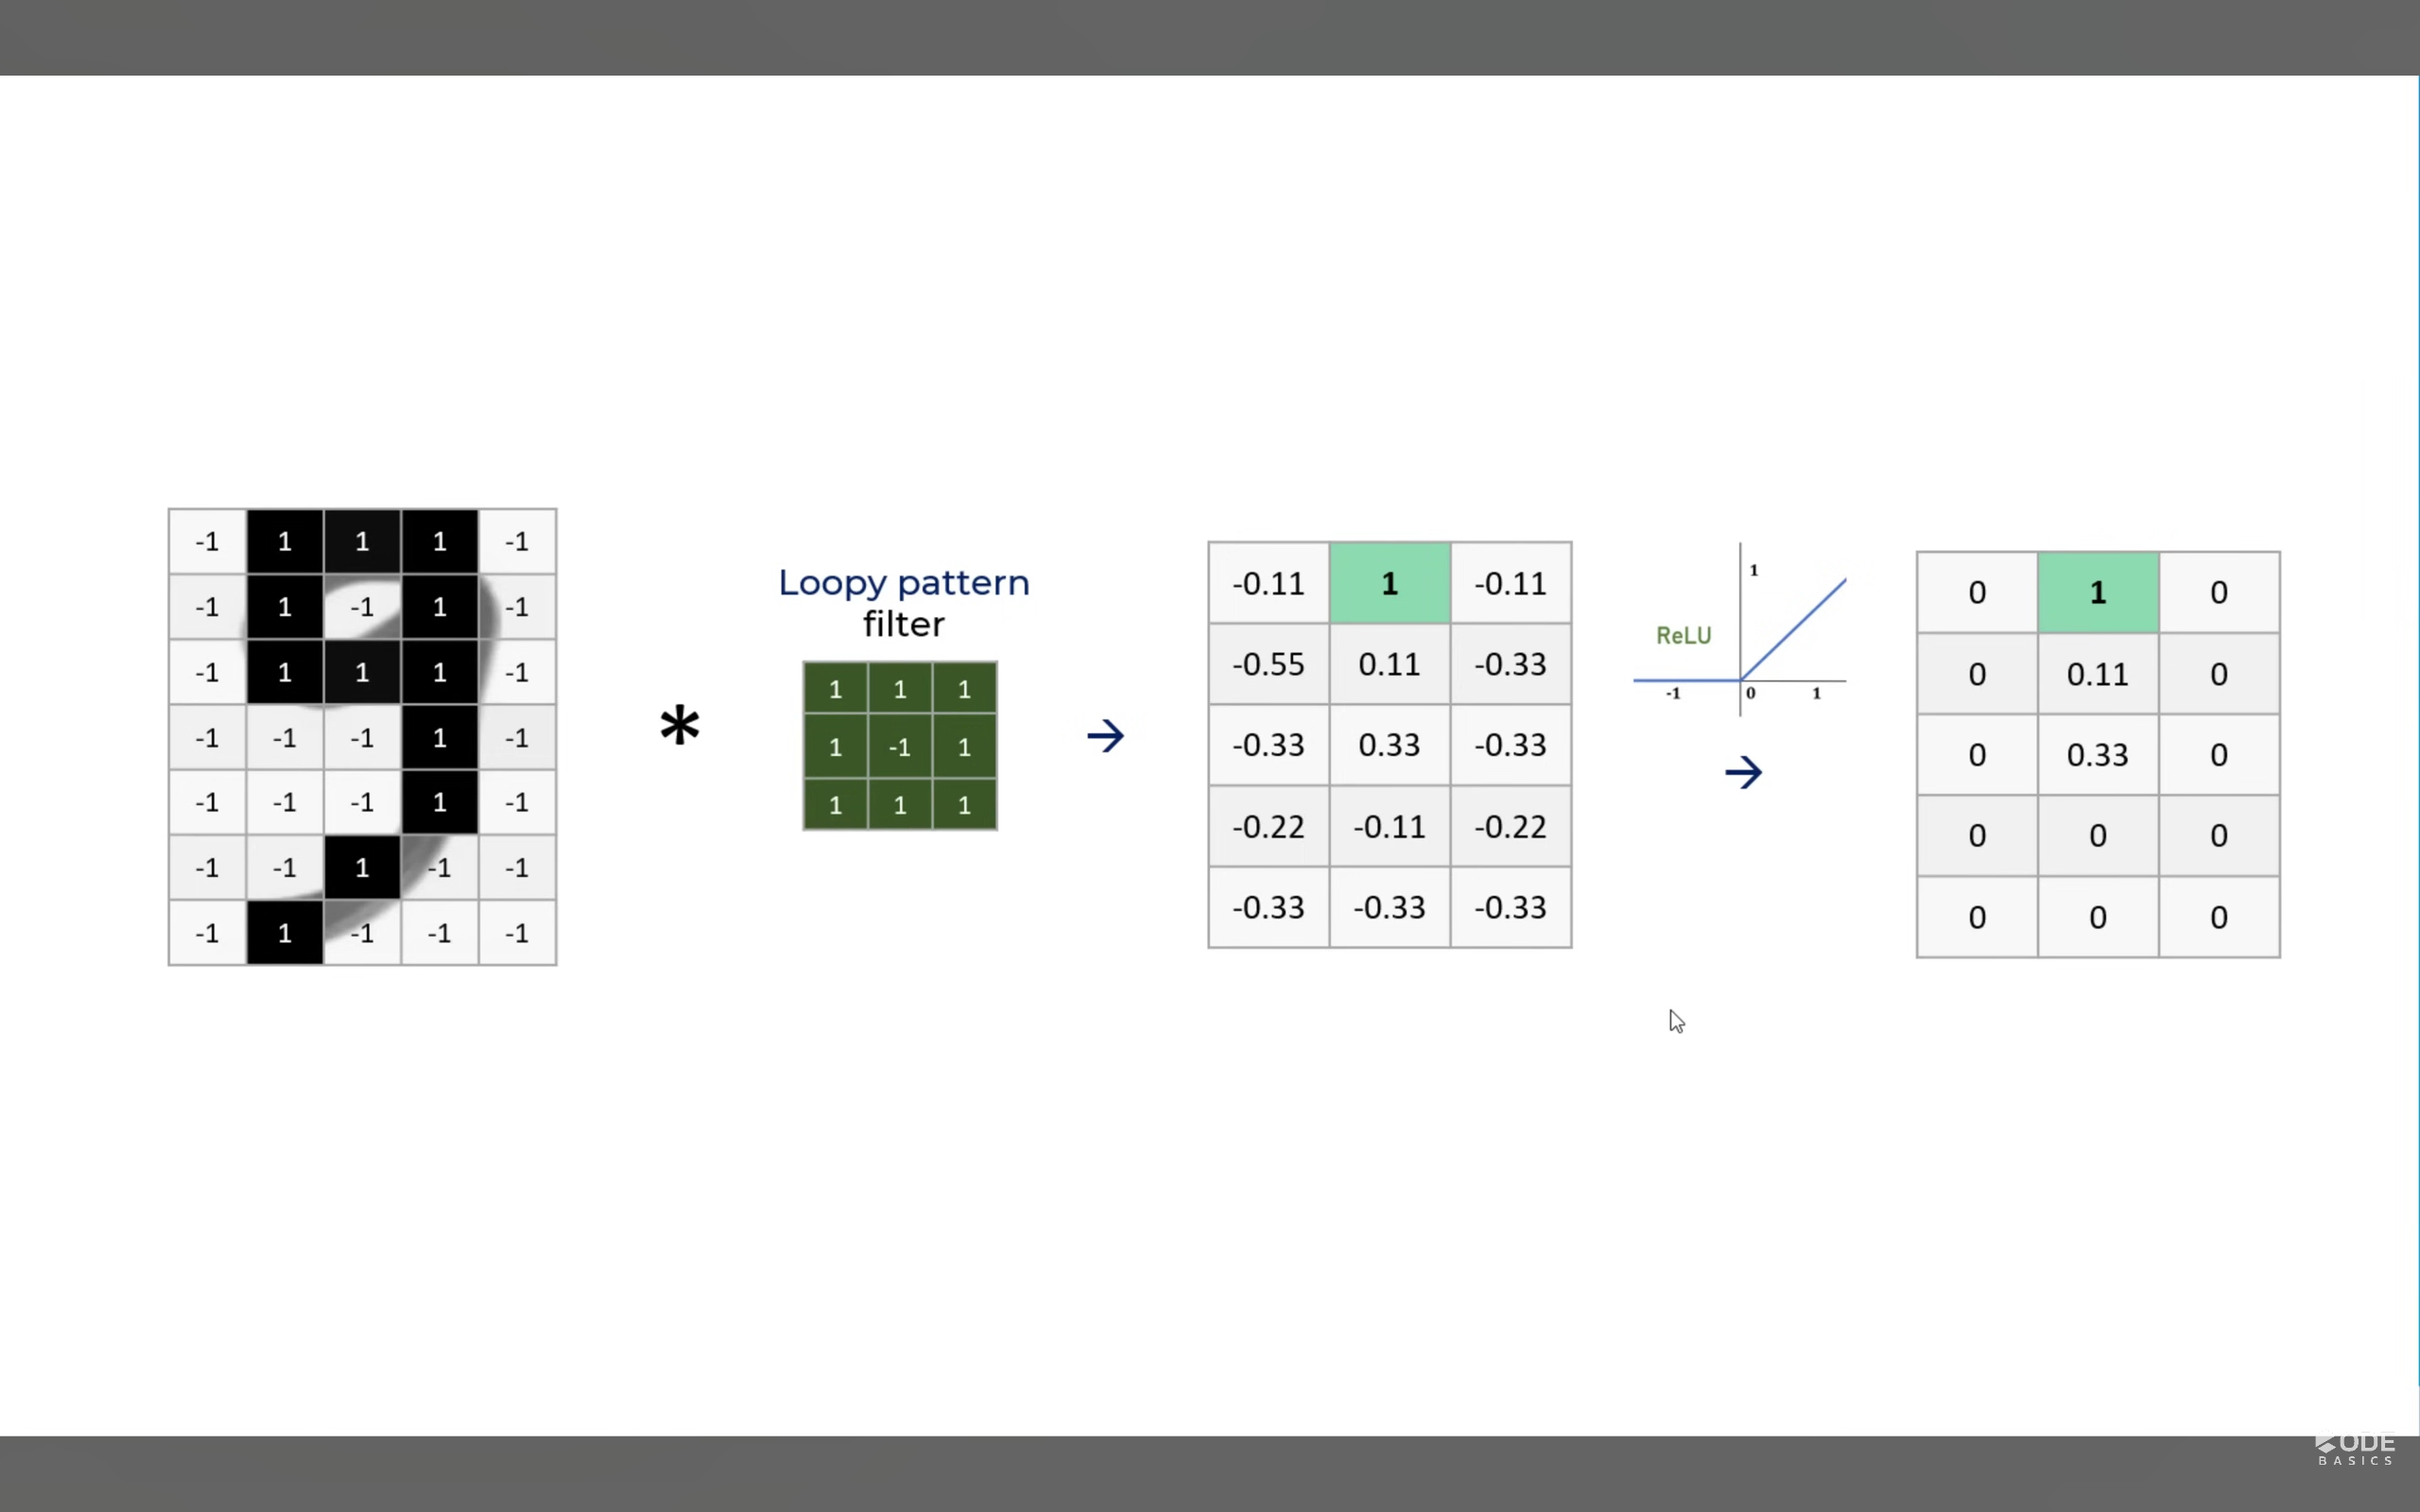

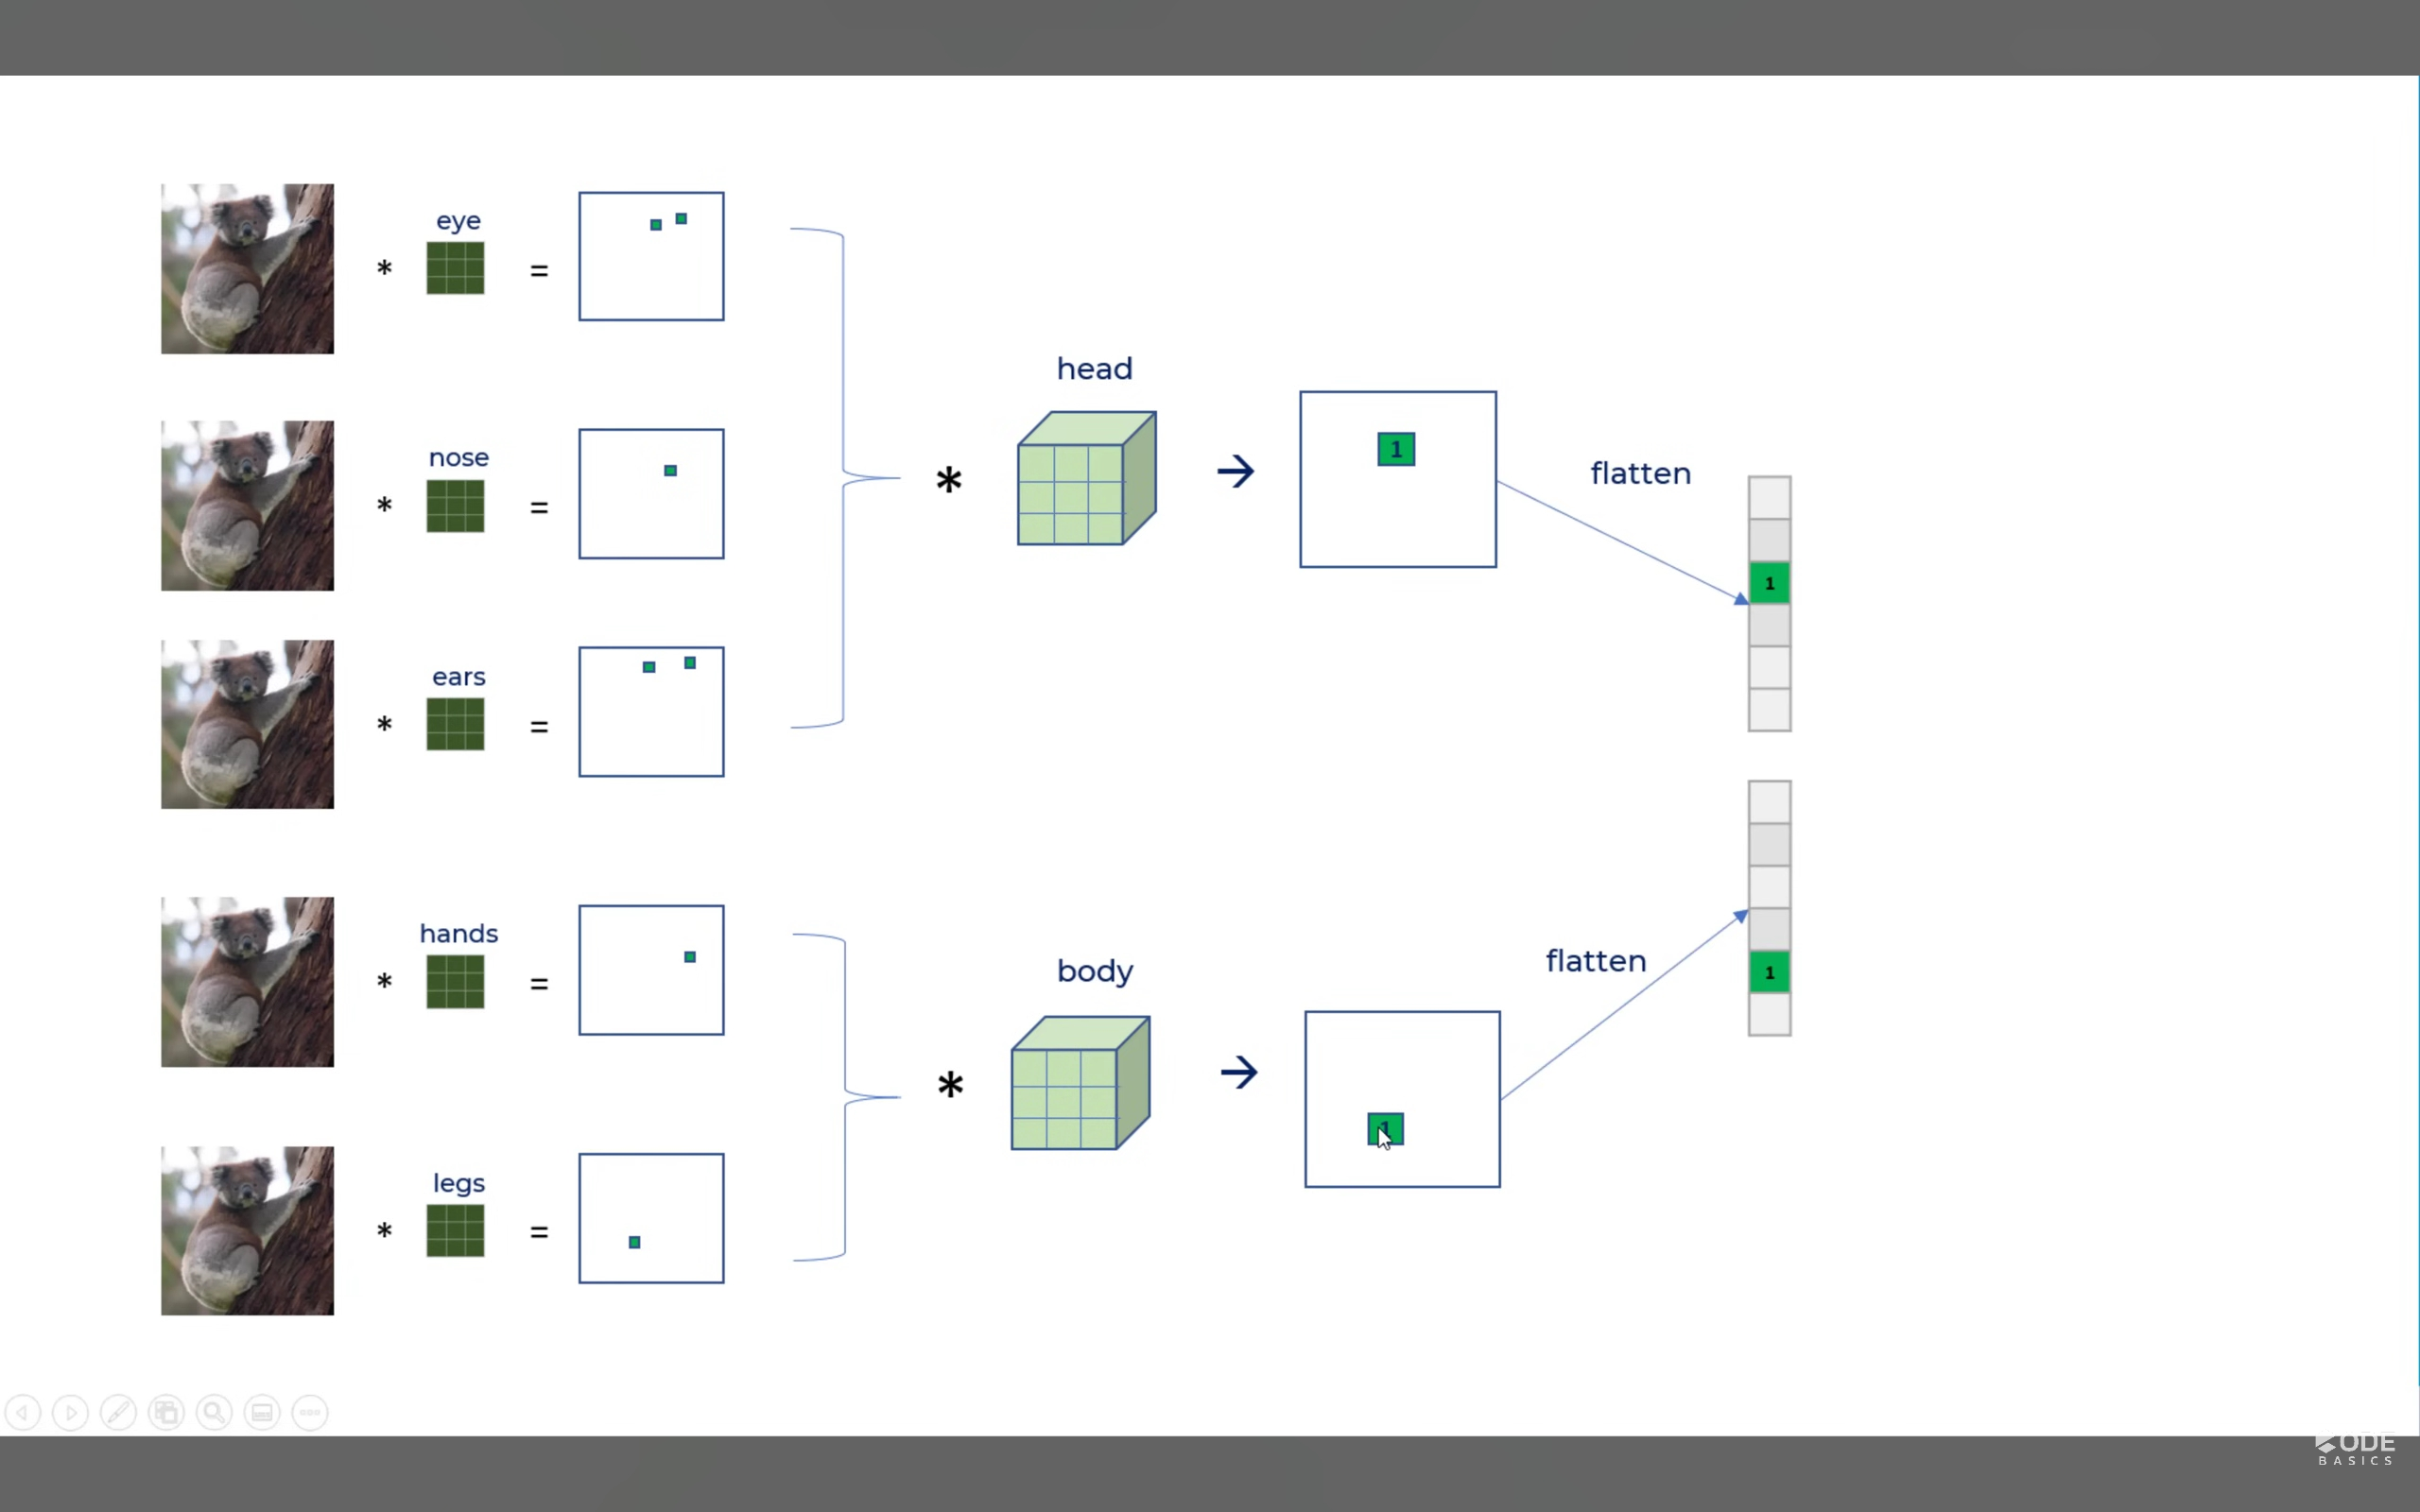

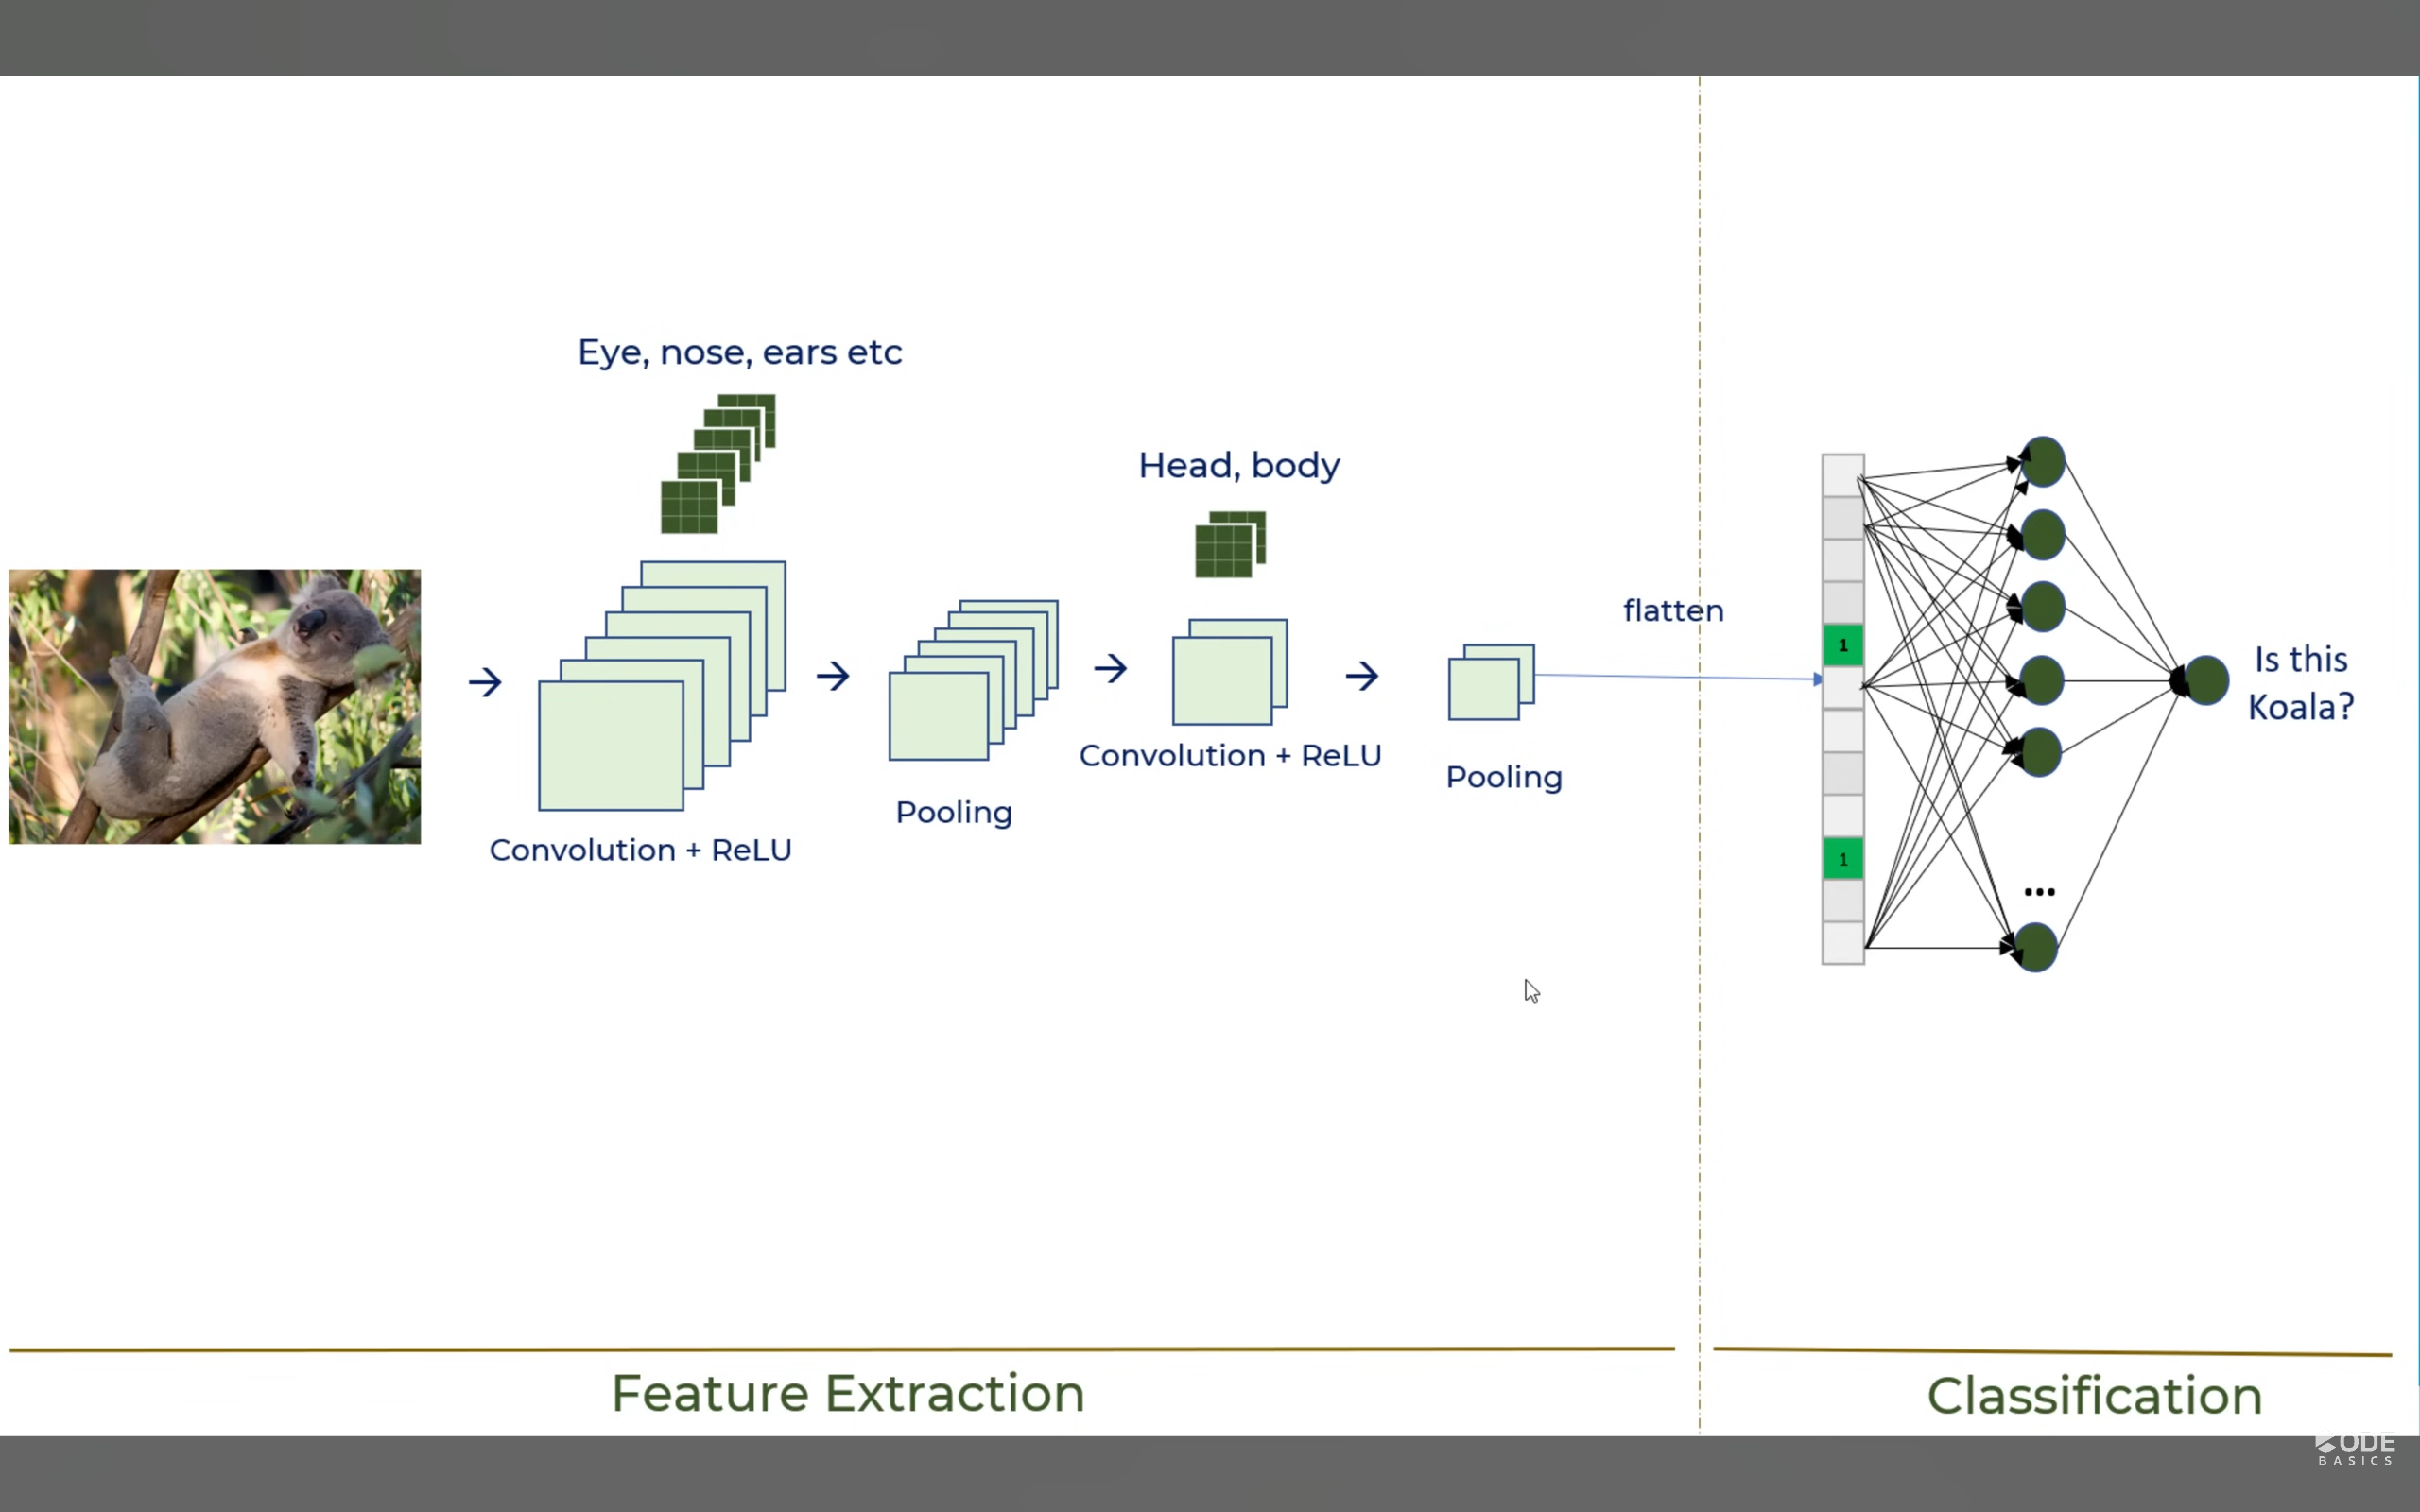

In [13]:
from IPython.display import Image, display

display(Image(filename='assets/filters.jpg'))
display(Image(filename='assets/feature_maps.jpg'))
display(Image(filename='assets/head_feature_map.jpg'))
display(Image(filename='assets/ReLu.jpg'))
display(Image(filename='assets/flattening.jpg'))
display(Image(filename='assets/CNN_process.jpg'))

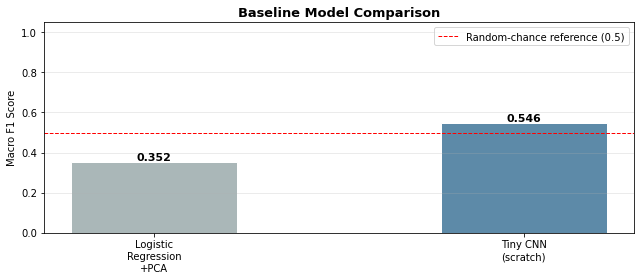

In [14]:
# Visual comparison
scores  = [lr_f1, tiny_f1]
labels  = ['Logistic\nRegression\n+PCA', 'Tiny CNN\n(scratch)']
colors  = ['#aab7b8', '#5d8aa8', '#2e86c1']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, scores, color=colors, edgecolor='white', width=0.45)

ax.set_ylim(0, 1.05)
ax.set_ylabel('Macro F1 Score')
ax.set_title('Baseline Model Comparison', fontsize=13, fontweight='bold')
ax.axhline(0.5, color='red', ls='--', lw=1, label='Random-chance reference (0.5)')
ax.legend()

for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


These baselines set the floor that MobileNetV2 must exceed

---
## 5: Transfer Learning

### 5.1 Architecture Overview 

Rather than training a CNN from scratch (which would require far more data), this project uses **transfer learning**: a MobileNetV2 model pre-trained on ImageNet is used as a feature extractor, and a custom classification head is attached on top.

**Why MobileNetV2?**
- Designed to be computationally efficient, making it suitable for deployment on edge devices (smartphones, used by farmers in the field)
- The depthwise separable convolutions in MobileNetV2 capture rich spatial features with fewer parameters than standard convolutions
- ImageNet pre-training encodes general visual features (edges, textures, shapes) that transfer well to leaf imagery

**Two-phase training strategy:**

| Phase | Base model | Learning rate | Purpose |
|---|---|---|---|
| Phase 1 (Head training) | Frozen | 1e-3 | Train the new classification head only; avoids corrupting ImageNet weights with a large gradient |
| Phase 2 (Fine-tuning) | Top layers unfrozen (from layer 130+) | 5e-5 | Gently adapt the upper convolutional blocks to potato leaf features while preserving low-level features |


### 5.2 Build Model

In [15]:
def build_model(num_classes=3, trainable_base=False):
    # Base: MobileNetV2 pretrained on ImageNet
    base = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = trainable_base

    # Classification head 
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model, base

model, base_model = build_model(num_classes=3, trainable_base=False)
model.summary()

Model: "functional_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_3 (InputLayer)         [(None, 224, 224, 3)]     0         
_________________________________________________________________
mobilenetv2_1.00_224 (Functi (None, 7, 7, 1280)        2257984   
_________________________________________________________________
global_average_pooling2d_1 ( (None, 1280)              0         
_________________________________________________________________
batch_normalization (BatchNo (None, 1280)              5120      
_________________________________________________________________
dense_2 (Dense)              (None, 256)               327936    
_________________________________________________________________
dropout_1 (Dropout)          (None, 256)               0         
_________________________________________________________________
dense_3 (Dense)              (None, 128)              

**Head design choices:**

- `GlobalAveragePooling2D` reduces the spatial feature map from the base to a single vector, avoiding the large flatten layer that would otherwise dramatically increase parameter count.
- `BatchNormalization` stabilises training after the frozen base and before the dense layers.
- Two dense layers (256 â†’ 128) with `L2 regularisation` and `Dropout` provide capacity to learn disease-discriminative patterns while resisting overfitting on the small dataset.


### 5.3 Phase 1 - Head Training (Frozen Base)

In [16]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_HEAD),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', MacroF1Score(num_classes=3)]
)

callbacks_phase1 = [
    EarlyStopping(monitor='val_macro_f1', mode='max',
                  patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_macro_f1', mode='max',
                      factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(CHECKPOINT_PATH, monitor='val_macro_f1', mode='max',
                    save_best_only=True, verbose=1),
]


history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,

    callbacks=callbacks_phase1,
    verbose=1
)

Epoch 1/15
47/48 [============================>.] - ETA: 0s - loss: 0.6244 - accuracy: 0.8191 - macro_f1: 0.7416
Epoch 00001: val_macro_f1 improved from -inf to 0.85593, saving model to best_potato_model.h5
48/48 [==============================] - 20s 410ms/step - loss: 0.6271 - accuracy: 0.8181 - macro_f1: 0.7404 - val_loss: 0.3097 - val_accuracy: 0.8978 - val_macro_f1: 0.8559
Epoch 2/15
47/48 [============================>.] - ETA: 0s - loss: 0.4016 - accuracy: 0.8703 - macro_f1: 0.8030
Epoch 00002: val_macro_f1 improved from 0.85593 to 0.90912, saving model to best_potato_model.h5
48/48 [==============================] - 19s 396ms/step - loss: 0.4196 - accuracy: 0.8699 - macro_f1: 0.8022 - val_loss: 0.2529 - val_accuracy: 0.9381 - val_macro_f1: 0.9091
Epoch 3/15
47/48 [============================>.] - ETA: 0s - loss: 0.3479 - accuracy: 0.8949 - macro_f1: 0.8316
Epoch 00003: val_macro_f1 did not improve from 0.90912
48/48 [==============================] - 19s 394ms/step - loss: 0.3

### 5.4 Phase 2 - Fine-tuning (Unfreeze Top Layers)

In [17]:
phase1_best = max(history1.history['val_macro_f1'])

checkpoint_phase2 = ModelCheckpoint(
    CHECKPOINT_PATH,
    monitor='val_macro_f1',
    mode='max',
    save_best_only=True,
    verbose=1
)

checkpoint_phase2.best = phase1_best

In [18]:
# Unfreeze layers from UNFREEZE_FROM onward in the base model
base_model.trainable = True
for layer in base_model.layers[:UNFREEZE_FROM]:
    layer.trainable = False


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FINE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', MacroF1Score(num_classes=3)]
)


callbacks_phase2 = [
    EarlyStopping(monitor='val_macro_f1', mode='max',
                  patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_macro_f1', mode='max',
                      factor=0.3, patience=4, min_lr=1e-7, verbose=1),
    checkpoint_phase2,
]

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,

    callbacks=callbacks_phase2,
    initial_epoch=len(history1.history['loss']),
    verbose=1
)

Epoch 8/20
47/48 [============================>.] - ETA: 0s - loss: 0.3729 - accuracy: 0.8836 - macro_f1: 0.8246
Epoch 00008: val_macro_f1 did not improve from 0.90912
48/48 [==============================] - 22s 460ms/step - loss: 0.3725 - accuracy: 0.8838 - macro_f1: 0.8246 - val_loss: 0.2723 - val_accuracy: 0.9040 - val_macro_f1: 0.8415
Epoch 9/20
47/48 [============================>.] - ETA: 0s - loss: 0.2966 - accuracy: 0.9102 - macro_f1: 0.8531
Epoch 00009: val_macro_f1 improved from 0.90912 to 0.91484, saving model to best_potato_model.h5
48/48 [==============================] - 22s 459ms/step - loss: 0.2964 - accuracy: 0.9104 - macro_f1: 0.8532 - val_loss: 0.2091 - val_accuracy: 0.9536 - val_macro_f1: 0.9148
Epoch 10/20
47/48 [============================>.] - ETA: 0s - loss: 0.2483 - accuracy: 0.9342 - macro_f1: 0.8887
Epoch 00010: val_macro_f1 did not improve from 0.91484
48/48 [==============================] - 22s 449ms/step - loss: 0.2480 - accuracy: 0.9343 - macro_f1: 0.8

**Fine-tuning rationale:** Unfreezing only the upper MobileNetV2 layers (from index 130 onward) preserves the low-level feature detectors (edges, colours, textures) learned from ImageNet, while allowing the higher-level feature detectors to adapt to the specific visual characteristics of potato leaf disease. A much lower learning rate prevents catastrophic forgetting of the pre-trained weights.

---

## 6: Evaluation

#### 6.1 Collect Test-set Predictions

In [19]:
best_model = keras.models.load_model(
    CHECKPOINT_PATH,
    custom_objects={'MacroF1Score': MacroF1Score},
    compile=False
)

y_prob_all = best_model.predict(test_ds)
y_pred_all = np.argmax(y_prob_all, axis=1)

#### 6.2 Macro F1

In [20]:
macro_f1 = f1_score(y_test, y_pred_all, average='macro')
print('=' * 50)
print(f'  Macro F1 Score   : {macro_f1:.4f}')
print('=' * 50)

  Macro F1 Score   : 0.9380


In [21]:
# baseline  comparison
baseline_comp = pd.DataFrame([
    {'Model': 'Logistic Regression + PCA',       'Macro F1': lr_f1},
    {'Model': 'Tiny CNN (no transfer learning)', 'Macro F1': tiny_f1},
    {'Model': 'MobileNetV2',       'Macro F1': macro_f1}
])
baseline_comp

,Model,Macro F1
0,Logistic Regression + PCA,0.352049
1,Tiny CNN (no transfer learning),0.545977
2,MobileNetV2,0.938014


### 6.3 Confusion Matrix & Report (transfer learning)

              precision    recall  f1-score   support

Early Blight       0.97      0.98      0.97       150
 Late Blight       0.95      0.96      0.96       150
     Healthy       0.95      0.83      0.88        23

    accuracy                           0.96       323
   macro avg       0.96      0.92      0.94       323
weighted avg       0.96      0.96      0.96       323



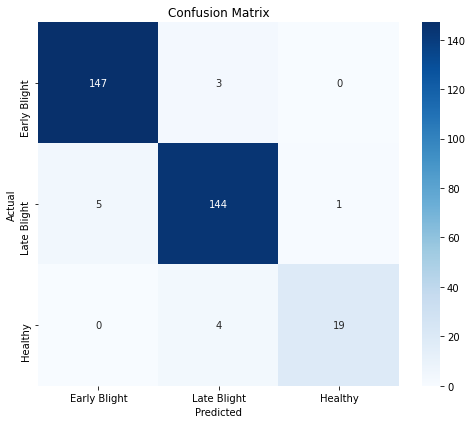

In [22]:
print(classification_report(y_test, y_pred_all, target_names=DISPLAY_NAMES))

cm = confusion_matrix(y_test, y_pred_all)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=DISPLAY_NAMES, yticklabels=DISPLAY_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

* Diagonal Cells (top-left to bottom-right) show correctly classified images.


* Off-diagonal cells show misclassifications. The most agronomically costly errors
are:
* Early/Late Blight predicted as Healthy (false negatives for disease - farmer
does not treat)
* Healthy predicted as Early/Late Blight (false positives - farmer applies
unnecessary fungicide)

There are 4 False Negatives. There are 5 False Positives, where Healthy leaves are
predicted as Late Blight.

### 6.4 Per-class F1 Bar Chart (transfer learning)

In [23]:
per_class_f1 = f1_score(y_test, y_pred_all, average=None)

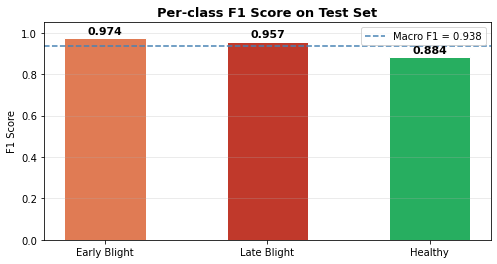

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
colors  = ['#e07b54', '#c0392b', '#27ae60']
bars = ax.bar(DISPLAY_NAMES, per_class_f1, color=colors, 
edgecolor='white', width=0.5)
ax.axhline(macro_f1, color='steelblue', linestyle='--', linewidth=1.5,
label=f'Macro F1 = {macro_f1:.3f}')
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1 Score')
ax.set_title('Per-class F1 Score on Test Set', fontsize=13, 
fontweight='bold')
ax.legend()
for bar, val in zip(bars, per_class_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
f'{val:.3f}', ha='center', va='bottom', fontsize=11, 
fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.show()

### 6.5 ROC Curves (transfer learning)

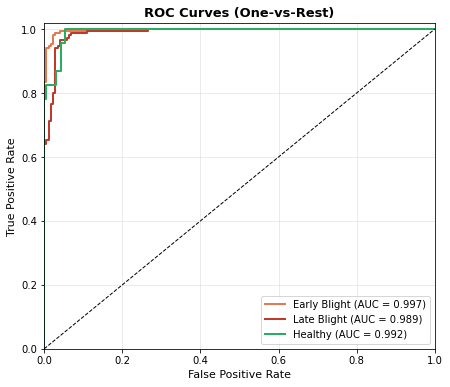

In [25]:
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(y_test, classes=[0, 1, 2])
colors_roc = ['#e07b54', '#c0392b', '#27ae60']

fig, ax = plt.subplots(figsize=(7, 6))
for i, (name, color) in enumerate(zip(DISPLAY_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob_all[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves (One-vs-Rest)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.show()

The ROC curve plots the True Positive Rate (recall) against the False Positive Rate at every possible classification threshold. A curve hugging the top-left corner represents a near-perfect classifier. The AUC (Area Under the Curve) summarises this into a single number between 0 and 1 - an AUC of 1.0 is perfect, 0.5 is no better than random guessing.

All classes have AUC > 0.97. Therefore the model is very good at distinguishing Healthy, Early Blight and Late Blight.

---

## 7: Gradient-weighted Class Activation Mapping

Gradient-weighted Class Activation Mapping (Grad-CAM) highlights which regions of the leaf the model focused on when making a prediction. This is particularly valuable for farmer-facing deployment â€” it shows where on the leaf the disease was detected, building trust in the output

In [26]:
from matplotlib import cm

# Flatten nested MobileNetV2 for Grad-CAM
mnv2 = best_model.get_layer('mobilenetv2_1.00_224')

flat_gradcam_model = keras.Model(
    inputs=mnv2.input,
    outputs=[mnv2.get_layer('Conv_1').output, mnv2.output]
)

head_input = keras.Input(shape=mnv2.output.shape[1:])
hx = head_input
for layer in best_model.layers:
    if not isinstance(layer, keras.Model):
        hx = layer(hx, training=False)
head_model = keras.Model(inputs=head_input, outputs=hx)


def get_gradcam_heatmap(img_array, pred_index=None): # computes the actual Grad-CAM heatmap
    with tf.GradientTape() as tape:
        conv_outputs, base_out = flat_gradcam_model(img_array, training=False)
        tape.watch(conv_outputs)
        preds = head_model(base_out, training=False)
        if pred_index is None:
            pred_index = int(tf.argmax(preds[0]))
        class_channel = preds[:, pred_index]

    grads        = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = tf.squeeze(tf.nn.relu(conv_outputs[0] @ pooled_grads[..., tf.newaxis]))
    heatmap      = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), pred_index


def overlay_gradcam(img_path, heatmap, alpha=0.45): # blends the heatmap on top of the original image
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    heatmap_c = (cm.get_cmap('jet')(cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE)))[:, :, :3] * 255).astype(np.uint8)
    return (alpha * heatmap_c + (1 - alpha) * img).astype(np.uint8)


def preprocess_path(img_path): #  loads an image from a file path and preprocesses it the same way the model was trained
    raw   = tf.io.read_file(img_path)
    image = tf.image.decode_image(raw, channels=3)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.keras.applications.mobilenet_v2.preprocess_input(tf.cast(image, tf.float32))
    return image


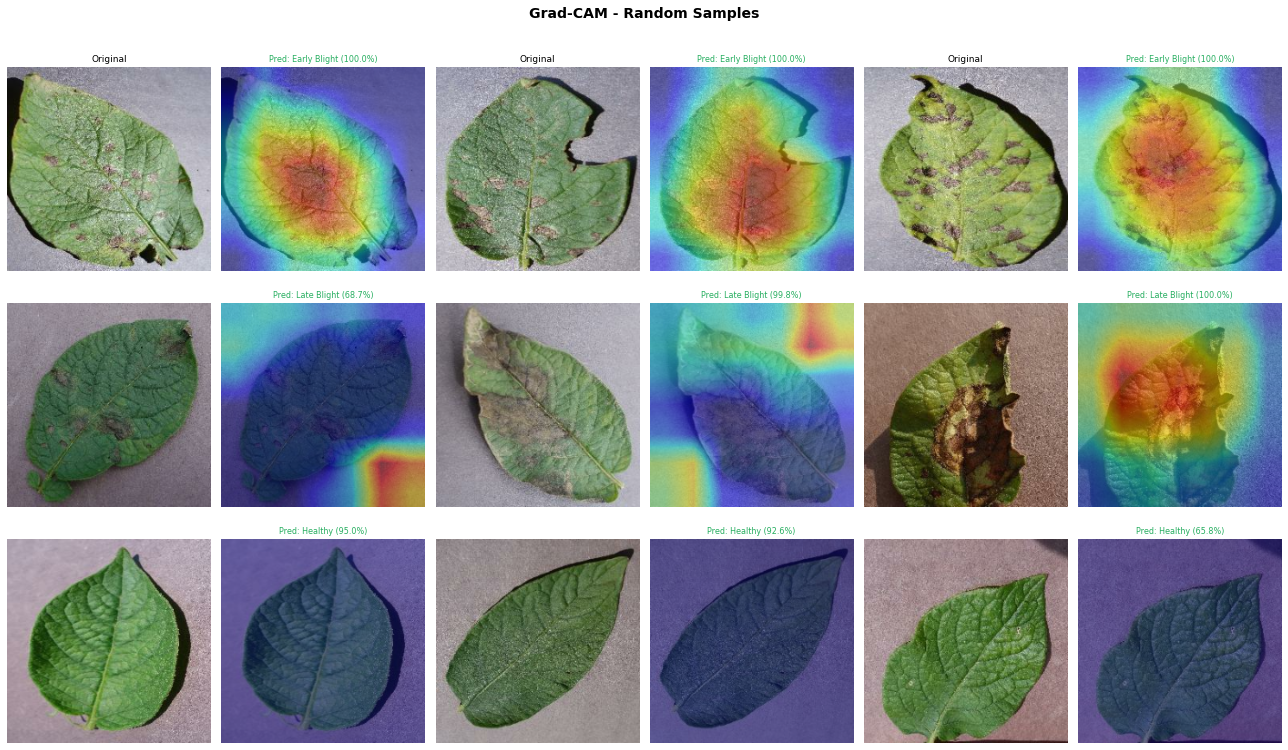

In [27]:
# Random samples per class
N_PER_CLASS = 3

fig, axes = plt.subplots(len(CLASS_NAMES), N_PER_CLASS * 2,
                         figsize=(N_PER_CLASS * 6, len(CLASS_NAMES) * 3.5))
fig.suptitle('Grad-CAM - Random Samples', fontsize=14, fontweight='bold', y=1.01)

for row, (cls, dname) in enumerate(zip(CLASS_NAMES, DISPLAY_NAMES)):
    cls_dir = os.path.join(DATASET_DIR, cls)
    for col, fname in enumerate(np.random.choice(os.listdir(cls_dir), N_PER_CLASS, replace=False)):
        img_path  = os.path.join(cls_dir, fname)
        image     = preprocess_path(img_path)
        img_batch = tf.expand_dims(image, 0)

        probs    = best_model(img_batch, training=False).numpy()[0]
        pred_idx = int(np.argmax(probs))
        conf     = float(probs[pred_idx])
        heatmap, _ = get_gradcam_heatmap(img_batch, pred_index=pred_idx)

        ax_orig = axes[row, col * 2]
        ax_orig.imshow(np.clip((image.numpy() + 1) / 2, 0, 1))
        ax_orig.axis('off')
        if col == 0:
            ax_orig.set_ylabel(dname, fontsize=10, fontweight='bold', rotation=0, labelpad=65, va='center')
        if row == 0:
            ax_orig.set_title('Original', fontsize=9)

        correct = (pred_idx == LABEL_MAP[cls])
        color   = '#27ae60' if correct else '#e74c3c'

        ax_cam = axes[row, col * 2 + 1]
        ax_cam.imshow(overlay_gradcam(img_path, heatmap))
        ax_cam.axis('off')
        if row == 0:
            ax_cam.set_title('Grad-CAM', fontsize=9)
        ax_cam.set_title(f'Pred: {DISPLAY_NAMES[pred_idx]} ({conf:.1%})', fontsize=8, color=color)

plt.tight_layout()
plt.show()

**'confidence':**

the softmax probability for the predicted class - i.e. `sample_probs[idx][pred]`, since the final activation is softmax. 

softmax converts the model's output scores into probabilities that sum to 1.

---
## 8: Limitations & Known Failure Modes

### 8.1 Dataset Distribution Mismatch

The model was trained and evaluated exclusively on **PlantVillage** images - controlled, close-up, single-leaf photographs taken against uniform backgrounds under consistent lighting. Real-world smartphone photos may differ from this distribution in several important ways:

| PlantVillage (training) | Real-world photos |
|---|---|
| Single leaf, plain background | Multiple leaves, cluttered background |
| Consistent studio-like lighting | Variable outdoor lighting, shadows |
| Leaf fills most of the frame | Leaf may be small or at an angle |

When tested on out-of-distribution images (wide-angle plant shots, stock photography), the model produced high-confidence false predictions. The **Grad-CAM heatmap** makes this detectable: on correct in-distribution predictions the heat clusters tightly on lesions or affected tissue; on out-of-distribution failures the heat is diffuse and spread across the whole image, indicating the model is reacting to general texture rather than disease features.

### 8.2 Practical Guidance for Users

For reliable predictions, users should:
- **Photograph a single leaf** close-up, filling most of the frame
- Use **even, natural light** - avoid harsh shadows or flash glare
- Keep the **background plain** where possible (e.g. hold the leaf against the sky or a plain surface)
- Check the **Grad-CAM overlay** - if the heat is not concentrated on a specific region of the leaf, treat the prediction with caution
- Be especially sceptical of **Healthy** predictions - see 9.2 above

### 8.3 Scope

The model classifies three classes only: Early Blight, Late Blight, and Healthy. It will assign one of these labels to any input image, including non-potato leaves or irrelevant photos. It is not designed to detect other potato diseases, nutrient deficiencies, or pest damage.

---
## 9: Export Metadata for Tableau

In [28]:
# Initialize data collection
metadata_records = []

for cls in CLASS_NAMES:
    cls_dir = os.path.join(DATASET_DIR, cls)
    display_name = DISPLAY_NAMES[CLASS_NAMES.index(cls)]
    
    file_list = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    for idx, fname in enumerate(file_list, 1):
        img_path = os.path.join(cls_dir, fname)
        
        try:
            # Open image - using PILImage now
            img = PIL.Image.open(img_path)
            img_array = np.array(img)
            
            # Calculate statistics
            record = {
                # Identifiers
                'image_id': fname,
                'image_path': img_path,
                'disease_class': cls,
                'display_name': display_name,
                
                # Image dimensions
                'width': img.size[0],
                'height': img.size[1],
                'aspect_ratio': round(img.size[0] / img.size[1], 3),
                'total_pixels': img.size[0] * img.size[1],
                'file_size_kb': round(os.path.getsize(img_path) / 1024, 2),
                
                # RGB channel means
                'mean_red': round(np.mean(img_array[:,:,0]), 2),
                'mean_green': round(np.mean(img_array[:,:,1]), 2),
                'mean_blue': round(np.mean(img_array[:,:,2]), 2),
                
                # RGB channel standard deviations
                'std_red': round(np.std(img_array[:,:,0]), 2),
                'std_green': round(np.std(img_array[:,:,1]), 2),
                'std_blue': round(np.std(img_array[:,:,2]), 2),
                
                # Overall brightness and contrast
                'brightness': round(np.mean(img_array), 2),
                'contrast': round(np.std(img_array), 2),
                
                # Color dominance (how much one channel exceeds others)
                'red_dominance': round(np.mean(img_array[:,:,0]) - np.mean(img_array[:,:,1:3]), 2),
                'green_dominance': round(np.mean(img_array[:,:,1]) - np.mean(img_array[:,:,[0,2]]), 2),
                'blue_dominance': round(np.mean(img_array[:,:,2]) - np.mean(img_array[:,:,[0,1]]), 2),
            }
            
            metadata_records.append(record)
            
        except Exception as e:
            print(f"  Error processing {fname}: {e}")
    
    print(f"  Processed {len(file_list)} images from {display_name}")

# Create DataFrame
metadata_df = pd.DataFrame(metadata_records)

# Check if we successfully loaded any data
if len(metadata_df) == 0:
    print("\n" + "="*70)
    print(" ✗ ERROR: No images were successfully processed!")
    print("="*70)
else:
    # Add derived categorical columns
    metadata_df['disease_severity'] = metadata_df['display_name'].apply(
        lambda x: 'Healthy' if x == 'Healthy' else 'Diseased'
    )

    metadata_df['size_category'] = pd.cut(
        metadata_df['file_size_kb'],
        bins=[0, 50, 100, 200, 500],
        labels=['Small', 'Medium', 'Large', 'Very Large']
    )

    metadata_df['brightness_level'] = pd.cut(
        metadata_df['brightness'],
        bins=[0, 100, 150, 200, 255],
        labels=['Dark', 'Moderate', 'Bright', 'Very Bright']
    )

    # Determine dominant color
    def get_dominant_color(row):
        if row['mean_green'] > row['mean_red'] and row['mean_green'] > row['mean_blue']:
            return 'Green'
        elif row['mean_red'] > row['mean_green'] and row['mean_red'] > row['mean_blue']:
            return 'Red'
        else:
            return 'Blue'

    metadata_df['dominant_color'] = metadata_df.apply(get_dominant_color, axis=1)

    # Average color intensity
    metadata_df['avg_color_intensity'] = round((metadata_df['mean_red'] + 
                                                 metadata_df['mean_green'] + 
                                                 metadata_df['mean_blue']) / 3, 2)

    # Save to CSV
    output_file = 'potato_eda_tableau.csv'
    metadata_df.to_csv(output_file, index=False)

    print("\n" + "="*70)
    print(f" ✓ METADATA SUCCESSFULLY EXTRACTED")
    print("="*70)
    print(f"  Total images processed : {len(metadata_df)}")
    print(f"  Output file           : {output_file}")
    print(f"  Columns created       : {len(metadata_df.columns)}")
    print("\n  Class Distribution:")
    print(metadata_df['display_name'].value_counts())

    print("\n  Summary Statistics:")
    summary_stats = metadata_df.groupby('display_name').agg({
        'brightness': 'mean',
        'contrast': 'mean',
        'mean_green': 'mean',
        'file_size_kb': 'mean'
    }).round(2)
    print(summary_stats)

    print("\n  First 5 rows:")
    print(metadata_df.head())

    print("\n" + "="*70)
    print(" READY FOR TABLEAU IMPORT")
    print("="*70)

  Processed 1000 images from Early Blight
  Processed 1000 images from Late Blight
  Processed 152 images from Healthy

 ✓ METADATA SUCCESSFULLY EXTRACTED
  Total images processed : 2152
  Output file           : potato_eda_tableau.csv
  Columns created       : 25

  Class Distribution:
display_name
Early Blight    1000
Late Blight     1000
Healthy          152
Name: count, dtype: int64

  Summary Statistics:
              brightness  contrast  mean_green  file_size_kb
display_name                                                
Early Blight      131.11     52.90      141.23         19.47
Healthy           123.23     47.58      132.42         19.55
Late Blight       113.91     43.77      119.28         16.08

  First 5 rows:
                                            image_id  \
0  001187a0-57ab-4329-baff-e7246a9edeb0___RS_Earl...   
1  002a55fb-7a3d-4a3a-aca8-ce2d5ebc6925___RS_Earl...   
2  009c8c31-f22d-4ffd-8f16-189c6f06c577___RS_Earl...   
3  00d8f10f-5038-4e0f-bb58-0b885ddc0cc5__